# 1 Imports and Utilities

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import time
from datetime import datetime
import re
import joblib
import hashlib
import matplotlib.pyplot as plt
import geopandas as gpd

# sklearn
from sklearn.pipeline import Pipeline
from sklearn.base import clone, BaseEstimator, RegressorMixin
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge, SGDRegressor
)
from sklearn.linear_model import MultiTaskLasso, MultiTaskElasticNet
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from IPython.display import display

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Dataset

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)


In [2]:
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

torch: 2.10.0+cu128
cuda available: True
gpu: Tesla V100-PCIE-32GB


In [3]:
# ============================================================
# Configurations
# ============================================================

OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

CSV_DIR = OUT_DIR / "regional_features_csv"   
SAVE_DIR = OUT_DIR / "modelling_outputs"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

TARGETS = ["t2m_mean", "rh2m_mean", "tp_sum_mm"]

ID_COLS = {"date", "time", "city", "region_id"}  # identifiers (not features)

# redundant / raw cols to drop from modelling
DROP_ALWAYS = {
    "ssrd_sum",          # redundant because ssrd_mj_m2 exists
    "month",
    "dayofyear",
}

KEEP_YEAR_AS_FEATURE = True  

RANDOM_STATE = 42

# 2 Data Preparation

In [4]:
# ============================================================
# Utilities and Helper Functions
# ============================================================

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def city_coverage(df, time_col="time"):
    d = df.copy()
    d[time_col] = pd.to_datetime(d[time_col])
    return (d.groupby("city")[time_col]
              .agg(["min","max","count"])
              .sort_values("min"))

def ensure_datetime(df, time_col="time"):
    d = df.copy()
    d[time_col] = pd.to_datetime(d[time_col])
    return d

def is_lag_roll(col: str) -> bool:
    return ("_lag" in col) or (("_mean" in col or "_sum" in col) and col.endswith("d"))

def make_next_day_supervised(df, time_col="time"):
    """
    Features at day t; labels are t+1 (next day) per (city, region_id).
    'target_date' is the day being predicted (t+1).
    """
    d = ensure_datetime(df, time_col=time_col)
    d = d.sort_values(["city", "region_id", time_col]).copy()

    # the date we are forecasting (label day)
    d["target_date"] = d[time_col] + pd.Timedelta(days=1)

    for t in TARGETS:
        d[f"{t}_tplus1"] = d.groupby(["city","region_id"])[t].shift(-1)

    d = d.dropna(subset=[f"{t}_tplus1" for t in TARGETS]).reset_index(drop=True)
    return d


def drop_first_k_days_per_region(df, k=14, time_col="time"):
    """
    For Level 2 validity: drop first 14 rows per (city, region) so rolling windows are valid.
    """
    d = ensure_datetime(df, time_col=time_col)
    d = d.sort_values(["city","region_id", time_col]).copy()
    d["_day_rank"] = d.groupby(["city","region_id"]).cumcount()
    d = d[d["_day_rank"] >= k].drop(columns=["_day_rank"]).reset_index(drop=True)
    return d


def clean_level_valid_rows(df_supervised, level=1, time_col="time", feature_cols=None):
    d = df_supervised.copy()

    if feature_cols is None:
        feature_cols = FEAT_BY_LEVEL[level]  # fallback

    # Level 2: ensure rolling windows valid
    if level == 2:
        d = drop_first_k_days_per_region(d, k=14, time_col=time_col)

    # Drop rows missing labels OR any used feature
    d = d.dropna(subset=LABEL_COLS + list(feature_cols)).reset_index(drop=True)
    return d

def split_train_val_test_by_city(
    df,
    train_candidates=("BKK","KL","HCM"),
    val_city=("BKK","KL","HCM"),   # can be str OR tuple/list
    test_city="HK"
):
    """
    City-only split (no time slicing):
      Train: cities in train_candidates
      Val  : cities in val_city (string or iterable)
      Test : city == test_city
    """
    present = sorted(df["city"].unique())

    train_cities = [c for c in train_candidates if c in present]
    if len(train_cities) == 0:
        raise ValueError(f"No train cities found among {train_candidates}. Present cities={present}")

    # allow val_city to be str or iterable
    if isinstance(val_city, str):
        val_cities = [val_city]
    else:
        val_cities = list(val_city)
    val_cities = [c for c in val_cities if c in present]

    train_df = df[df["city"].isin(train_cities)].copy()
    val_df   = df[df["city"].isin(val_cities)].copy() if len(val_cities) > 0 else df.iloc[0:0].copy()
    test_df  = df[df["city"] == test_city].copy() if test_city in present else df.iloc[0:0].copy()

    return train_df, val_df, test_df, train_cities

def split_by_city_and_timeblock(
    df,
    train_cities, val_cities, test_cities,
    train_end, val_end, test_end,
    date_col="target_date"
):
    """
    City + time-block split using the predicted day (target_date).

    Train: city in train_cities AND target_date <= train_end
    Val  : city in val_cities   AND train_end < target_date <= val_end
    Test : city in test_cities  AND val_end   < target_date <= test_end
    """
    d = df.copy()
    d[date_col] = pd.to_datetime(d[date_col])

    train_end = pd.to_datetime(train_end)
    val_end   = pd.to_datetime(val_end)
    test_end  = pd.to_datetime(test_end)

    train_mask = d["city"].isin(train_cities) & (d[date_col] <= train_end)
    val_mask   = d["city"].isin(val_cities)   & (d[date_col] >  train_end) & (d[date_col] <= val_end)
    test_mask  = d["city"].isin(test_cities)  & (d[date_col] >  val_end)   & (d[date_col] <= test_end)

    train_df = d.loc[train_mask].copy()
    val_df   = d.loc[val_mask].copy()
    test_df  = d.loc[test_mask].copy()

    return train_df, val_df, test_df

def split_summary(train_df, val_df, test_df, date_col="target_date"):
    def _summ(name, x):
        if len(x) == 0:
            return f"{name}: EMPTY"
        return (f"{name}: n={len(x)} | cities={sorted(x['city'].unique())} | "
                f"{date_col}={x[date_col].min().date()}→{x[date_col].max().date()}")
    print(_summ("TRAIN", train_df))
    print(_summ("VAL  ", val_df))
    print(_summ("TEST ", test_df))

def get_XY(df, feature_cols):
    X = df[feature_cols].astype(float).to_numpy()
    Y = df[[f"{t}_tplus1" for t in TARGETS]].astype(float).to_numpy()
    return X, Y


In [5]:
# ============================================================
# Load Datasets
# ============================================================

csv_files = sorted(CSV_DIR.glob("*.csv"))
if len(csv_files) == 0:
    raise FileNotFoundError(f"No CSVs found in {CSV_DIR}. Check your EDA export path.")

dfs = []
for p in csv_files:
    df = pd.read_csv(p)

    # Ensure datetime
    if "time" not in df.columns:
        raise ValueError(f"{p.name} missing 'time' column.")
    df["time"] = pd.to_datetime(df["time"])

    # Ensure city exists (either in file or infer from filename)
    if "city" not in df.columns:
        # Example inference: "BKK.csv" -> "BKK"
        df["city"] = p.stem.split("_")[0]

    dfs.append(df)

full_regional = pd.concat(dfs, ignore_index=True)
print("Loaded full_regional:", full_regional.shape)
print("Cities:", sorted(full_regional["city"].unique()))
display(city_coverage(full_regional))


Loaded full_regional: (1241952, 61)
Cities: ['BKK', 'HCM', 'HK', 'KL']


,min,max,count
city,,,
BKK,2000-01-01,2024-12-31,401808
HCM,2000-01-01,2024-12-31,447468
HK,2000-01-01,2024-12-31,118716
KL,2000-01-01,2024-12-31,273960


In [6]:
# Build next-day supervised dataset (labels = t+1)
df_supervised = make_next_day_supervised(full_regional, time_col="time")


In [7]:
df_supervised.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1241816 entries, 0 to 1241815
Data columns (total 65 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   time                1241816 non-null  datetime64[ns]
 1   region_id           1241816 non-null  object        
 2   t2m_mean            1241816 non-null  float64       
 3   rh2m_mean           1241816 non-null  float64       
 4   tp_sum_mm           1241816 non-null  float64       
 5   sp_mean             1241816 non-null  float64       
 6   u10_mean            1241816 non-null  float64       
 7   v10_mean            1241816 non-null  float64       
 8   city                1241816 non-null  object        
 9   ssrd_mj_m2          1241816 non-null  float64       
 10  t2m_mean_lag1       1241680 non-null  float64       
 11  t2m_mean_lag3       1241408 non-null  float64       
 12  t2m_mean_lag7       1240864 non-null  float64       
 13  t2m_mean_lag

In [8]:
# ============================================================
# Data Preprocessing
# ============================================================

def enforce_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()

    # datetimes
    if "time" in d.columns:
        d["time"] = pd.to_datetime(d["time"])
    if "target_date" in d.columns:
        d["target_date"] = pd.to_datetime(d["target_date"])

    # identifiers
    if "city" in d.columns:
        d["city"] = d["city"].astype("category")

    # region_id is an identifier, keep as category (never feature)
    if "region_id" in d.columns:
        d["region_id"] = d["region_id"].astype("category")

    # year/month/dayofyear dtypes (if present)
    for c in ["year", "month", "dayofyear"]:
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors="coerce").astype("int16")

    return d

def preprocess_supervised(df: pd.DataFrame) -> pd.DataFrame:
    d = enforce_dtypes(df)
    if "year" not in d.columns:
        d["year"] = pd.to_datetime(d["time"]).dt.year.astype("int16")
    return d


In [9]:
# ============================================================
# Feature Selection for L1 and L2 Features
# ============================================================

def get_feature_cols(df, level=1, label_suffix="_tplus1"):
    """
    STRICT predictors:
      - exclude ID cols
      - exclude label columns
      - Level 1 excludes lag/rolling columns
      - Level 2 keeps lag/rolling columns
    """
    label_cols = [f"{t}{label_suffix}" for t in TARGETS]

    # numeric only
    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

    feat = [c for c in num_cols if c not in ID_COLS and c not in label_cols]

    if level == 1:
        feat = [c for c in feat if not is_lag_roll(c)]
    elif level == 2:
        pass
    else:
        raise ValueError("level must be 1 or 2")

    return sorted(feat)

def assert_feature_sanity(df, feature_cols, allow_current_targets=True):
    # always forbidden
    forbidden = set(ID_COLS) | set([f"{t}_tplus1" for t in TARGETS])

    # optionally forbid current-day targets
    if not allow_current_targets:
        forbidden |= set(TARGETS)

    bad = set(feature_cols) & forbidden
    if bad:
        raise ValueError(f"Invalid/leaky features detected: {sorted(bad)}")

    nonnum = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(df[c])]
    if nonnum:
        raise ValueError(f"Non-numeric features detected: {nonnum[:10]}")


In [10]:
df_supervised = preprocess_supervised(df_supervised)
print("df_supervised:", df_supervised.shape)
display(city_coverage(df_supervised))

df_supervised: (1241816, 66)


/tmp/ipykernel_3155912/3730170330.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return (d.groupby("city")[time_col]


,min,max,count
city,,,
BKK,2000-01-01,2024-12-30,401764
HCM,2000-01-01,2024-12-30,447419
HK,2000-01-01,2024-12-30,118703
KL,2000-01-01,2024-12-30,273930


In [11]:
feat_L1 = get_feature_cols(df_supervised, level=1)
feat_L2 = get_feature_cols(df_supervised, level=2)

print("L1 n_features =", len(feat_L1))
print(feat_L1)

print("\nL2 n_features =", len(feat_L2))
print(feat_L2)

FEAT_BY_LEVEL = {1: feat_L1, 2: feat_L2}
LABEL_COLS = [f"{t}_tplus1" for t in TARGETS]

L1 n_features = 10
['doy_cos', 'doy_sin', 'rh2m_mean', 'sp_mean', 'ssrd_mj_m2', 't2m_mean', 'tp_sum_mm', 'u10_mean', 'v10_mean', 'year']

L2 n_features = 59
['doy_cos', 'doy_sin', 'rh2m_mean', 'rh2m_mean_lag1', 'rh2m_mean_lag14', 'rh2m_mean_lag3', 'rh2m_mean_lag7', 'rh2m_mean_mean14d', 'rh2m_mean_mean3d', 'rh2m_mean_mean7d', 'sp_mean', 'sp_mean_lag1', 'sp_mean_lag14', 'sp_mean_lag3', 'sp_mean_lag7', 'sp_mean_mean14d', 'sp_mean_mean3d', 'sp_mean_mean7d', 'ssrd_mj_m2', 'ssrd_mj_m2_lag1', 'ssrd_mj_m2_lag14', 'ssrd_mj_m2_lag3', 'ssrd_mj_m2_lag7', 'ssrd_mj_m2_mean14d', 'ssrd_mj_m2_mean3d', 'ssrd_mj_m2_mean7d', 't2m_mean', 't2m_mean_lag1', 't2m_mean_lag14', 't2m_mean_lag3', 't2m_mean_lag7', 't2m_mean_mean14d', 't2m_mean_mean3d', 't2m_mean_mean7d', 'tp_sum_mm', 'tp_sum_mm_lag1', 'tp_sum_mm_lag14', 'tp_sum_mm_lag3', 'tp_sum_mm_lag7', 'tp_sum_mm_sum14d', 'tp_sum_mm_sum3d', 'tp_sum_mm_sum7d', 'u10_mean', 'u10_mean_lag1', 'u10_mean_lag14', 'u10_mean_lag3', 'u10_mean_lag7', 'u10_mean_mean14d', 'u1

In [12]:
label_cols = [f"{t}_tplus1" for t in TARGETS]

# L1 clean: drop rows missing any L1 feature or label
df_L1_clean = df_supervised.dropna(subset=feat_L1 + label_cols).copy()

# L2 clean: first drop first 14 days per (city, region) then drop rows missing any L2 feature or label
df_tmp = drop_first_k_days_per_region(df_supervised, k=14, time_col="time")
df_L2_clean = df_tmp.dropna(subset=feat_L2 + label_cols).copy()

print("df_supervised:", df_supervised.shape)
print("df_L1_clean  :", df_L1_clean.shape)
print("df_L2_clean  :", df_L2_clean.shape)

/tmp/ipykernel_3155912/3730170330.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d["_day_rank"] = d.groupby(["city","region_id"]).cumcount()


df_supervised: (1241816, 66)
df_L1_clean  : (1241816, 66)
df_L2_clean  : (1239912, 66)


In [13]:
df_L2_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1239912 entries, 0 to 1239911
Data columns (total 66 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   time                1239912 non-null  datetime64[ns]
 1   region_id           1239912 non-null  category      
 2   t2m_mean            1239912 non-null  float64       
 3   rh2m_mean           1239912 non-null  float64       
 4   tp_sum_mm           1239912 non-null  float64       
 5   sp_mean             1239912 non-null  float64       
 6   u10_mean            1239912 non-null  float64       
 7   v10_mean            1239912 non-null  float64       
 8   city                1239912 non-null  category      
 9   ssrd_mj_m2          1239912 non-null  float64       
 10  t2m_mean_lag1       1239912 non-null  float64       
 11  t2m_mean_lag3       1239912 non-null  float64       
 12  t2m_mean_lag7       1239912 non-null  float64       
 13  t2m_mean_lag

In [14]:
df_supervised.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1241816 entries, 0 to 1241815
Data columns (total 66 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   time                1241816 non-null  datetime64[ns]
 1   region_id           1241816 non-null  category      
 2   t2m_mean            1241816 non-null  float64       
 3   rh2m_mean           1241816 non-null  float64       
 4   tp_sum_mm           1241816 non-null  float64       
 5   sp_mean             1241816 non-null  float64       
 6   u10_mean            1241816 non-null  float64       
 7   v10_mean            1241816 non-null  float64       
 8   city                1241816 non-null  category      
 9   ssrd_mj_m2          1241816 non-null  float64       
 10  t2m_mean_lag1       1241680 non-null  float64       
 11  t2m_mean_lag3       1241408 non-null  float64       
 12  t2m_mean_lag7       1240864 non-null  float64       
 13  t2m_mean_lag

# 3 Model Training

## 3.1 Flat Models

In [15]:
# ============================================================
# Helper Functions for Event Metrics (POD/FAR/CSI) per target from continuous predictions
# ============================================================

def pod_far_csi(y_true_bin, y_pred_bin):
    y_true_bin = np.asarray(y_true_bin).astype(int)
    y_pred_bin = np.asarray(y_pred_bin).astype(int)
    tp = int(((y_pred_bin==1) & (y_true_bin==1)).sum())
    fp = int(((y_pred_bin==1) & (y_true_bin==0)).sum())
    fn = int(((y_pred_bin==0) & (y_true_bin==1)).sum())
    pod = tp / (tp + fn + 1e-9)
    far = fp / (tp + fp + 1e-9)
    csi = tp / (tp + fp + fn + 1e-9)
    return float(pod), float(far), float(csi)


def per_target_event_metrics(y_true, y_pred, train_df, targets,
                             # default event thresholds
                             q_hi=(0.90, 0.95),
                             rain_wet_thr=0.1):
    """
    Computes POD/FAR/CSI for EACH target separately using TRAIN-derived thresholds only.

    For tp_sum_mm:
      - wet >= 0.1
      - heavy_rain >= p95 of wet days
      - extreme_rain >= p99 of wet days

    For other targets:
      - high_q90, high_q95 based on TRAIN quantiles
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if y_true.ndim == 1:
        y_true = y_true.reshape(-1, 1)
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)

    rows = []
    for j, t in enumerate(targets):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        train_y = train_df[f"{t}_tplus1"].to_numpy(dtype=float)

        # define thresholded "events" per target
        events = []
        if t == "tp_sum_mm":
            wet = train_y >= rain_wet_thr
            p95 = np.quantile(train_y[wet], 0.95) if wet.any() else 5.0
            p99 = np.quantile(train_y[wet], 0.99) if wet.any() else 20.0
            events = [
                ("wet", rain_wet_thr),
                ("heavy_rain_p95wet", float(p95)),
                ("extreme_rain_p99wet", float(p99)),
            ]
        else:
            thr1 = float(np.quantile(train_y, q_hi[0]))
            thr2 = float(np.quantile(train_y, q_hi[1]))
            events = [
                (f"high_q{int(q_hi[0]*100)}", thr1),
                (f"high_q{int(q_hi[1]*100)}", thr2),
            ]

        for ev_name, thr in events:
            pod, far, csi = pod_far_csi((yt >= thr), (yp >= thr))
            rows.append({
                "target": t,
                "event": ev_name,
                "threshold": float(thr),
                "POD": pod, "FAR": far, "CSI": csi
            })

    return pd.DataFrame(rows)

In [16]:
# ============================================================
# Helper Functions for Regression Error Metrics
# ============================================================

def reg_metrics_df(y_true, y_pred, targets, model_name):
    """
    y_true/y_pred: arrays (n, len(targets))
    """
    rows = []
    for i, t in enumerate(targets):
        yt = y_true[:, i]
        yp = y_pred[:, i]
        rows.append({
            "model": model_name,
            "target": t,
            "MAE": float(mean_absolute_error(yt, yp)),
            "RMSE": float(np.sqrt(mean_squared_error(yt, yp))),
            "R2": float(r2_score(yt, yp)),
        })
    return pd.DataFrame(rows)

In [17]:
# ============================================================
# MLP Class
# ============================================================

class TorchMLPRegressor(BaseEstimator, RegressorMixin):
    """
    sklearn-style regressor implemented in PyTorch.
    - Works with sklearn Pipeline
    - Works with clone()
    - Uses GPU automatically if available
    - Supports single-output AND multi-output regression (y can be (n,) or (n, k))
    - Internally scales y for easier training, but returns predictions in original units
    """

    def __init__(
        self,
        hidden_layer_sizes=(256, 128),
        activation="relu",          # "relu" or "tanh"
        lr=1e-3,
        weight_decay=1e-4,
        batch_size=256,
        max_epochs=40,
        patience=5,
        dropout=0.1,
        scale_y=True,
        use_amp=True,              # mixed precision on CUDA
        random_state=42,
        verbose=0,
    ):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.activation = activation
        self.lr = lr
        self.weight_decay = weight_decay
        self.batch_size = batch_size
        self.max_epochs = max_epochs
        self.patience = patience
        self.dropout = dropout
        self.scale_y = scale_y
        self.use_amp = use_amp
        self.random_state = random_state
        self.verbose = verbose

    def _act(self):
        if self.activation == "relu":
            return nn.ReLU()
        if self.activation == "tanh":
            return nn.Tanh()
        raise ValueError(f"Unsupported activation: {self.activation}")

    def _build_net(self, input_dim, out_dim):
        layers = []
        in_dim = input_dim
        for h in self.hidden_layer_sizes:
            layers.append(nn.Linear(in_dim, int(h)))
            layers.append(self._act())
            if self.dropout and self.dropout > 0:
                layers.append(nn.Dropout(float(self.dropout)))
            in_dim = int(h)
        layers.append(nn.Linear(in_dim, out_dim))
        return nn.Sequential(*layers)

    def fit(self, X, y):
        # ---- prepare numpy ----
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.float32)

        if y.ndim == 1:
            y = y.reshape(-1, 1)  # (n,1)

        n, d = X.shape
        out_dim = y.shape[1]

        # ---- device ----
        self.device_ = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        if self.verbose:
            print(f"[TorchMLP] device={self.device_} | X={X.shape} | y={y.shape}")

        # ---- scale y (fit only on train) ----
        self.y_scaler_ = None
        y_train = y
        if self.scale_y:
            self.y_scaler_ = StandardScaler()
            y_train = self.y_scaler_.fit_transform(y)

        # ---- internal train/early-stop split ----
        rng = np.random.default_rng(self.random_state)
        idx = rng.permutation(n)

        val_n = max(1, int(0.1 * n))
        val_idx = idx[:val_n]
        tr_idx = idx[val_n:]

        Xtr, ytr = X[tr_idx], y_train[tr_idx]
        Xva, yva = X[val_idx], y_train[val_idx]

        # ---- torch tensors ----
        tr_ds = TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr))
        va_ds = TensorDataset(torch.from_numpy(Xva), torch.from_numpy(yva))

        tr_loader = DataLoader(
            tr_ds,
            batch_size=int(self.batch_size),
            shuffle=True,
            drop_last=False,
            pin_memory=(self.device_.type == "cuda"),
        )
        va_loader = DataLoader(
            va_ds,
            batch_size=int(self.batch_size),
            shuffle=False,
            drop_last=False,
            pin_memory=(self.device_.type == "cuda"),
        )

        # ---- model ----
        self.model_ = self._build_net(input_dim=d, out_dim=out_dim).to(self.device_)
        opt = torch.optim.Adam(self.model_.parameters(), lr=float(self.lr), weight_decay=float(self.weight_decay))
        loss_fn = nn.MSELoss()

        use_amp = bool(self.use_amp) and (self.device_.type == "cuda")
        scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

        best_state = None
        best_val = np.inf
        bad = 0

        for ep in range(1, int(self.max_epochs) + 1):
            # ---- train ----
            self.model_.train()
            for xb, yb in tr_loader:
                xb = xb.to(self.device_, non_blocking=True)
                yb = yb.to(self.device_, non_blocking=True)

                opt.zero_grad(set_to_none=True)

                if use_amp:
                    with torch.cuda.amp.autocast():
                        pred = self.model_(xb)
                        loss = loss_fn(pred, yb)
                    scaler.scale(loss).backward()
                    scaler.step(opt)
                    scaler.update()
                else:
                    pred = self.model_(xb)
                    loss = loss_fn(pred, yb)
                    loss.backward()
                    opt.step()

            # ---- val RMSE (in scaled space) ----
            self.model_.eval()
            se = 0.0
            cnt = 0
            with torch.no_grad():
                for xb, yb in va_loader:
                    xb = xb.to(self.device_, non_blocking=True)
                    yb = yb.to(self.device_, non_blocking=True)
                    pred = self.model_(xb)
                    se += torch.sum((pred - yb) ** 2).item()
                    cnt += yb.numel()

            val_rmse = float(np.sqrt(se / max(cnt, 1)))

            if self.verbose and (ep == 1 or ep % 5 == 0):
                print(f"[TorchMLP] ep={ep:03d} val_rmse_scaled={val_rmse:.5f}")

            if val_rmse < best_val - 1e-6:
                best_val = val_rmse
                best_state = {k: v.detach().cpu().clone() for k, v in self.model_.state_dict().items()}
                bad = 0
            else:
                bad += 1
                if bad >= int(self.patience):
                    if self.verbose:
                        print("[TorchMLP] early stop")
                    break

        # load best
        if best_state is not None:
            self.model_.load_state_dict(best_state)

        # for pickling/joblib: keep state dict on CPU
        self.state_dict_ = {k: v.detach().cpu().clone() for k, v in self.model_.state_dict().items()}
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=np.float32)

        # rebuild model if needed (e.g., after joblib load)
        if not hasattr(self, "model_") or self.model_ is None:
            # infer dims from state dict
            # (we stored state_dict_ so we can rebuild reliably)
            first_w = self.state_dict_[next(iter(self.state_dict_))]
            # input_dim is not directly in tensor shape for deep nets, so we rebuild using X.shape[1]
            input_dim = X.shape[1]
            # out_dim from last layer bias
            last_bias = self.state_dict_[sorted(self.state_dict_.keys())[-1]]
            out_dim = int(last_bias.shape[0]) if last_bias.ndim == 1 else 1
            self.device_ = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            self.model_ = self._build_net(input_dim=input_dim, out_dim=out_dim).to(self.device_)
            self.model_.load_state_dict(self.state_dict_)

        self.model_.eval()
        ds = TensorDataset(torch.from_numpy(X))
        loader = DataLoader(
            ds,
            batch_size=int(self.batch_size),
            shuffle=False,
            drop_last=False,
            pin_memory=(getattr(self, "device_", torch.device("cpu")).type == "cuda"),
        )

        preds = []
        with torch.no_grad():
            for (xb,) in loader:
                xb = xb.to(self.device_, non_blocking=True)
                yp = self.model_(xb).detach().cpu().numpy()
                preds.append(yp)

        yhat = np.vstack(preds)

        # inverse scale back to original units
        if getattr(self, "y_scaler_", None) is not None:
            yhat = self.y_scaler_.inverse_transform(yhat)

        # if single-output, return 1D to behave like sklearn regressors
        if yhat.shape[1] == 1:
            return yhat.ravel()
        return yhat

In [18]:
# ============================================================
# Model Spaces for Hyperparameter Tuning via RandomSearch
# ============================================================

def linear_variants(multi: bool):
    """
    Returns a dict: name -> (model, param_space, search_type)

    multi=True  => models must accept y shape (n, 3)
    multi=False => models accept y shape (n,)
    """
    models = {}

    if not multi:
        # --- single-output ---
        models["LinearRegression"] = (LinearRegression(), {}, "none")

        models["Ridge"] = (
            Ridge(random_state=RANDOM_STATE),
            {"model__alpha": np.logspace(-4, 4, 60)}, 
            "random",
        )

        models["Lasso"] = (
            Lasso(max_iter=20000, random_state=RANDOM_STATE),
            {"model__alpha": np.logspace(-6, 0, 80)},
            "random",
        )
                
        models["ElasticNet"] = (
            ElasticNet(max_iter=20000, random_state=RANDOM_STATE),
            {
                "model__alpha": np.logspace(-6, 0, 60),
                "model__l1_ratio": np.linspace(0.05, 0.95, 19).tolist(),
            },
            "random",
        )

        models["BayesianRidge"] = (BayesianRidge(), {}, "none")

        models["SGDRegressor"] = (
            SGDRegressor(max_iter=30000, tol=1e-4, random_state=RANDOM_STATE),
            {"model__penalty": ["l2", "l1", "elasticnet"],
             "model__alpha": np.logspace(-7, -3, 30),
             "model__l1_ratio": [0.15, 0.3, 0.5, 0.7, 0.85]},
            "random",
        )
        return models

    # --- multi-output safe variants ---

    # These support multi-output natively (y is 2D)
    models["LinearRegression"] = (LinearRegression(), {}, "none")

    models["Ridge"] = (
        Ridge(random_state=RANDOM_STATE),
        {"model__alpha": np.logspace(-4, 4, 60)},  
        "random",
    )

    # Use multitask versions for true multi-target lasso/enet
    models["MultiTaskLasso"] = (
        MultiTaskLasso(max_iter=20000, random_state=RANDOM_STATE),
        {"model__alpha": np.logspace(-6, 0, 80)},
        "random",
    )
            
    models["MultiTaskElasticNet"] = (
        MultiTaskElasticNet(max_iter=20000, random_state=RANDOM_STATE),
        {
            "model__alpha": np.logspace(-6, 0, 60),
            "model__l1_ratio": np.linspace(0.05, 0.95, 19).tolist(),
        },
        "random",
    )
    
    # These are single-output => wrap
    models["BayesianRidge"] = (
        MultiOutputRegressor(BayesianRidge()),
        {},
        "none",
    )

    models["SGDRegressor"] = (
        MultiOutputRegressor(SGDRegressor(max_iter=30000, tol=1e-4, random_state=RANDOM_STATE)),
        {"model__estimator__penalty": ["l2", "l1", "elasticnet"],
         "model__estimator__alpha": np.logspace(-7, -3, 30),
         "model__estimator__l1_ratio": [0.15, 0.3, 0.5, 0.7, 0.85]},
        "random",
    )

    return models

def xgb_space(multi=True, use_gpu=True):
    """
    XGBoost regressor + tuning space.
    - For multi-output: wrap with MultiOutputRegressor (one model per target).
    - No scaling needed.
    """
    predictor   = "gpu_predictor" if use_gpu else "auto"

    base = XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        predictor=predictor,
        device="cuda" if use_gpu else "cpu",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    )

    if multi:
        model = MultiOutputRegressor(base)
        prefix = "model__estimator__"
    else:
        model = base
        prefix = "model__"

    space = {
        f"{prefix}n_estimators": [300, 600, 900],
        f"{prefix}learning_rate": [0.01, 0.03, 0.05, 0.1],
        f"{prefix}max_depth": [3, 4, 5, 6, 8],
        f"{prefix}min_child_weight": [1, 3, 5, 7],
        f"{prefix}subsample": [0.6, 0.8, 1.0],
        f"{prefix}colsample_bytree": [0.6, 0.8, 1.0],
        f"{prefix}gamma": [0.0, 0.1, 0.2, 0.5],
        f"{prefix}reg_alpha": [0.0, 1e-3, 1e-2, 1e-1],
        f"{prefix}reg_lambda": [0.5, 1.0, 2.0, 5.0],
    }
    return model, space


def rf_space():
    # n_jobs=1 avoids parallel memory spikes
    model = RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1,
        bootstrap=True
    )
    space = {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [10, 14, 18, None],
        "model__min_samples_split": [5, 10, 20],
        "model__min_samples_leaf": [2, 4, 8],
        "model__max_features": ["sqrt", 0.3, 0.5],
        "model__max_samples": [0.4, 0.6, 0.8],
    }
    return model, space

def mlp_space(multi=True):
    model = TorchMLPRegressor(
        hidden_layer_sizes=(256, 128),
        activation="relu",
        lr=1e-3,
        weight_decay=1e-4,
        batch_size=256,
        max_epochs=40,
        patience=5,
        dropout=0.1,
        scale_y=True,
        use_amp=True,
        random_state=RANDOM_STATE,
        verbose=0,   
    )

    space = {
        "model__hidden_layer_sizes": [(128,), (256,), (256,128), (512,256), (256,128,64)],
        "model__activation": ["relu", "tanh"],
        "model__lr": [1e-3, 3e-4, 1e-4],
        "model__weight_decay": [0.0, 1e-5, 1e-4, 1e-3],
        "model__batch_size": [128, 256, 512],
        "model__dropout": [0.0, 0.1, 0.2],
        "model__max_epochs": [20, 40, 60],
        "model__patience": [5, 8],
    }
    return model, space



In [19]:
# ============================================================
# Hyperparameter Tuning Helper Functions
# ============================================================

def _ts():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

def append_df_to_csv(path, df, subset_cols):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists():
        old = pd.read_csv(path)
        new = pd.concat([old, df], ignore_index=True)
        new = new.drop_duplicates(subset=subset_cols, keep="last")
        new.to_csv(path, index=False)
    else:
        df.to_csv(path, index=False)

def tune_with_val_logged(pipe, param_space, search, Xtr, ytr, Xva, yva,
                         n_iter=40, print_every=25,
                         normalize_multi=False, y_scale=None):
    """
    Random search ONLY (for all models).
    - Generates up to n_iter UNIQUE candidates (best-effort).
    - Scores on validation RMSE (or mean-normalized RMSE for multi when normalize_multi=True).
    """
    if not param_space:
        print(f"[{_ts()}]   No tuning params -> fitting once")
        pipe.fit(Xtr, ytr)
        pred = pipe.predict(Xva)

        if yva.ndim == 1:
            best_score = rmse(yva, pred)
        else:
            pred = np.asarray(pred)
            rmses = np.array([rmse(yva[:, j], pred[:, j]) for j in range(yva.shape[1])], dtype=float)
            if normalize_multi:
                if y_scale is None:
                    y_scale = np.std(ytr, axis=0) + 1e-9
                best_score = float(np.mean(rmses / y_scale))
            else:
                best_score = float(np.mean(rmses))

        return pipe, {"best_val_score": float(best_score), "best_params": {}}

    rng = np.random.default_rng(RANDOM_STATE)
    keys = list(param_space.keys())
    vals = [list(param_space[k]) for k in keys]

    # max unique combos (cap to avoid huge integers)
    max_unique = 1
    for v in vals:
        max_unique = min(max_unique * max(len(v), 1), 10_000_000)

    target = int(min(n_iter, max_unique))
    candidates = []
    seen = set()
    attempts = 0
    max_attempts = target * 50  # best-effort uniqueness

    while len(candidates) < target and attempts < max_attempts:
        cand = {}
        for k, v in zip(keys, vals):
            cand[k] = v[int(rng.integers(0, len(v)))]
        sig = tuple(sorted(cand.items()))
        if sig not in seen:
            seen.add(sig)
            candidates.append(cand)
        attempts += 1

    print(f"[{_ts()}]   Random search candidates={len(candidates)} (requested={n_iter})")

    best_score = np.inf
    best_params = None
    best_model = None

    for i, params in enumerate(candidates, start=1):
        m = clone(pipe)
        m.set_params(**params)
        m.fit(Xtr, ytr)
        pred = m.predict(Xva)

        if yva.ndim == 1:
            score = rmse(yva, pred)
        else:
            pred = np.asarray(pred)
            rmses = np.array([rmse(yva[:, j], pred[:, j]) for j in range(yva.shape[1])], dtype=float)
            if normalize_multi:
                if y_scale is None:
                    y_scale = np.std(ytr, axis=0) + 1e-9
                score = float(np.mean(rmses / y_scale))
            else:
                score = float(np.mean(rmses))

        if score < best_score:
            best_score = score
            best_params = params
            best_model = m

        if i % print_every == 0 or i == len(candidates):
            print(f"[{_ts()}]     tried {i:>4}/{len(candidates)} | best_val_score={best_score:.4f}")

    return best_model, {"best_val_score": float(best_score), "best_params": best_params}

In [20]:
# ============================================================
# Model Saving Helper Functions
# ============================================================

def _safe_fname(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", s)

CACHE_DIR = SAVE_DIR / "model_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def _old_cache_path(tag: str) -> Path:
    return CACHE_DIR / f"{_safe_fname(tag)}.joblib"

def _new_cache_path(tag: str, keep=80, hlen=12) -> Path:
    safe = _safe_fname(tag)[:keep]
    h = hashlib.md5(tag.encode("utf-8")).hexdigest()[:hlen]
    return CACHE_DIR / f"{safe}__{h}.joblib"

def try_load_model(tag: str):
    """
    Backward compatible:
      1) try new short-name cache
      2) try old long-name cache
      3) if found old, optionally copy to new for future
    """
    p_new = _new_cache_path(tag)
    if p_new.exists():
        obj = joblib.load(p_new)
        if isinstance(obj, dict) and "model" in obj:
            return obj
        return {"model": obj, "tune_info": {"best_val_score": np.nan, "best_params": {}}}

    p_old = _old_cache_path(tag)
    if p_old.exists():
        obj = joblib.load(p_old)
        out = obj if (isinstance(obj, dict) and "model" in obj) else {"model": obj, "tune_info": {"best_val_score": np.nan, "best_params": {}}}
        # optional: migrate to new short filename (so next time it loads fast)
        try:
            joblib.dump(out, p_new)
        except Exception:
            pass
        return out

    return None

def save_model(tag: str, model, tune_info: dict):
    p = _new_cache_path(tag)
    p.parent.mkdir(parents=True, exist_ok=True)

    obj = {"model": model, "tune_info": tune_info, "tag": tag}
    joblib.dump(obj, p)

    try:
        index_path = CACHE_DIR / "cache_index.csv"
        row = pd.DataFrame([{"tag": tag, "filename": p.name}])
        if index_path.exists():
            old = pd.read_csv(index_path)
            new = pd.concat([old, row], ignore_index=True).drop_duplicates(subset=["tag"], keep="last")
            new.to_csv(index_path, index=False)
        else:
            row.to_csv(index_path, index=False)
    except Exception:
        pass

    return p

def _city_list_str(x):
    # accept str / list / tuple
    if isinstance(x, str):
        return x
    if isinstance(x, (list, tuple)):
        return "-".join([str(i) for i in x])
    return str(x)

def make_exp_slug(level, mode, split_mode,
                  train_cities, val_cities, test_city,
                  train_end, val_end, test_end,
                  split_sig_hash, feat_sig,
                  keep=140):
    """
    Creates a short, Windows-safe experiment filename stem.
    """
    tr = _city_list_str(train_cities)
    va = _city_list_str(val_cities)
    te = _city_list_str(test_city)

    raw = (
        f"L{level}_{mode}_{split_mode}"
        f"__TR-{tr}__VA-{va}__TE-{te}"
        f"__trEnd{train_end}__vaEnd{val_end}__teEnd{test_end}"
        f"__split{split_sig_hash}__feat{feat_sig}"
    )
    safe = _safe_fname(raw)

    # if still too long, hard-shorten + hash
    if len(safe) > keep:
        h = hashlib.md5(safe.encode("utf-8")).hexdigest()[:12]
        safe = safe[:keep] + f"__{h}"

    return safe

In [21]:
# ============================================================
# Run Experiment Helper Function
# ============================================================

def run_experiment(df_supervised, level=1, mode="multi",
                   train_candidates=("BKK","KL","HCM"), val_city=("BKK","KL","HCM"), test_city="HK",
                   n_iter=40, time_col="time", feature_cols=None, allow_current_targets=True,
                   run_id=None, save_dir=None, do_importance=False,
                   split_mode="city_only",
                   train_end="2016-12-31", val_end="2020-12-31", test_end="2024-12-31"):

    """
      - prints logs per model
      - saves after EACH model finishes
      - can resume (skips models already saved)
    """
    if run_id is None:
        run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
    if save_dir is None:
        save_dir = Path(SAVE_DIR) / f"run_{run_id}"
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n[{_ts()}] ===== RUN L{level} {mode} | run_id={run_id} | save_dir={save_dir} =====")

    if feature_cols is None:
        feature_cols = FEAT_BY_LEVEL[level]
    
    d = clean_level_valid_rows(df_supervised, level=level, time_col=time_col, feature_cols=feature_cols)
    
    # --- SPLIT ---
    if split_mode == "city_timeblock":
        # Cross-city generalisation + time-block:
        # Train/Val on (BKK, KL, HCM), Test on HK, all split by target_date
        train_cities = [c for c in train_candidates if c in d["city"].unique()]
        if len(train_cities) == 0:
            raise ValueError(f"No train cities among (BKK,KL,HCM). Present={sorted(d['city'].unique())}")

    
        train_df, val_df, test_df = split_by_city_and_timeblock(
            d,
            train_cities=train_cities,
            val_cities=train_cities,
            test_cities=[test_city],
            train_end=train_end,
            val_end=val_end,
            test_end=test_end,
            date_col="target_date"
        )
        split_summary(train_df, val_df, test_df, date_col="target_date")
        val_city_str = ",".join(train_cities)
        
    
    else:
        train_df, val_df, test_df, train_cities = split_train_val_test_by_city(
            d, train_candidates=train_candidates, val_city=val_city, test_city=test_city
        )
        val_city_str = val_city if isinstance(val_city, str) else ",".join(val_city)

    # ---- signatures for naming ----
    split_sig = f"{split_mode}|tr{train_end}|va{val_end}|te{test_end}|train{','.join(train_cities)}|val{val_city_str}|test{test_city}|L{level}|{mode}"
    split_sig_hash = hashlib.md5(split_sig.encode("utf-8")).hexdigest()[:10]
        
    if len(val_df) == 0:
        raise ValueError(f"Validation set is empty. Check split_mode={split_mode} and date cutoffs.")
    if len(test_df) == 0:
        raise ValueError(f"Test set is empty. Check split_mode={split_mode} and date cutoffs.")


    assert_feature_sanity(d, feature_cols, allow_current_targets=allow_current_targets)

    Xtr, Ytr = get_XY(train_df, feature_cols)
    Xva, Yva = get_XY(val_df, feature_cols)
    Xte, Yte = get_XY(test_df, feature_cols)
    
    feat_sig = hashlib.md5("|".join(feature_cols).encode("utf-8")).hexdigest()[:10]
    exp_slug = make_exp_slug(level, mode, split_mode, train_cities, val_city_str.split(",") if isinstance(val_city_str, str) else val_city_str,
                             test_city, train_end, val_end, test_end, split_sig_hash, feat_sig)
    
    # Output paths 
    reg_path = save_dir / f"{exp_slug}__reg.csv"
    ev_path  = save_dir / f"{exp_slug}__events.csv"
    imp_path = save_dir / f"{exp_slug}__importance.csv"
    
    # Resume support: what models already done? (per experiment file)
    done_models = set()
    if reg_path.exists():
        try:
            done_models = set(pd.read_csv(reg_path)["model"].unique())
        except Exception:
            done_models = set()

    results_reg = []
    results_ev = []
    results_imp = []
    fitted = {}

    def fit_one(model_name, base_model, param_space, search, scale=True, target_idx=None):
        t0 = time.perf_counter()
        tune_info = {"best_val_score": np.nan, "best_params": {}}
    
        steps = []
        if scale:
            steps.append(("scaler", StandardScaler()))
        steps.append(("model", base_model))
        pipe = Pipeline(steps)
    
        if mode == "single":
            ytr = Ytr[:, target_idx]
            yva = Yva[:, target_idx]
            yte = Yte[:, target_idx]
            y_scale = float(np.std(ytr)) + 1e-9
        else:
            ytr, yva, yte = Ytr, Yva, Yte
            y_scale = np.std(ytr, axis=0) + 1e-9  # per-target std
    
        tag = f"L{level}-{model_name}-{mode}"
        cache_key = f"{tag}__{exp_slug}"
    
        # --- 1) If model pkl exists, load it and skip retraining ---
        loaded = try_load_model(cache_key)
        if loaded is not None:
            print(f"[{_ts()}] LOAD  {tag} (model cache found)")
            tuned = loaded["model"]
            tune_info = loaded.get("tune_info", tune_info)
        
            if tag in done_models:
                dt = time.perf_counter() - t0
                print(f"[{_ts()}] SKIP  {tag} (metrics already saved) | elapsed={dt/60:.2f} min")
                return tuned, None, None, None, True
        
            pred = tuned.predict(Xte)
    
        else:
            # If metrics exist but cache missing, retrain to recover model
            if tag in done_models:
                print(f"[{_ts()}] WARN  {tag} metrics exist but cache missing -> retraining to recover model")
                done_models.discard(tag)  # treat as not done so we proceed normally
        
            print(f"[{_ts()}] START {tag}")
        
            tuned, tune_info = tune_with_val_logged(
                pipe, param_space, search,
                Xtr, ytr, Xva, yva,
                n_iter=n_iter,
                print_every=25,
                normalize_multi=(mode == "multi"),
                y_scale=y_scale
            )
        
            pred = tuned.predict(Xte)
        
            saved_path = save_model(cache_key, tuned, tune_info)
            print(f"[{_ts()}]   Saved model -> {saved_path.name}")
    
        # --- 4) Standardize pred shapes ---
        pred_va = tuned.predict(Xva)
        
        # --- 4) Standardize pred/test shapes ---
        if mode == "single":
            pred2 = np.asarray(pred).reshape(-1, 1)
            ytrue2 = yte.reshape(-1, 1)
        
            pred_va2 = np.asarray(pred_va).reshape(-1, 1)
            yva2 = yva.reshape(-1, 1)
        
            tlist = [TARGETS[target_idx]]
        else:
            pred2 = np.asarray(pred)
            ytrue2 = yte
        
            pred_va2 = np.asarray(pred_va)
            yva2 = yva
        
            tlist = TARGETS
        
        # Regression (TEST metrics)
        reg_df = reg_metrics_df(ytrue2, pred2, tlist, model_name=tag)
        reg_df["train_cities"] = ",".join(train_cities)
        reg_df["val_city"] = val_city_str
        reg_df["test_city"] = test_city
        reg_df["val_best_score"] = tune_info.get("best_val_score", np.nan)
        reg_df["best_params"] = str(tune_info.get("best_params", {}))
        
        # Validation RMSEs for reporting
        if mode == "multi":
            val_rmses = [rmse(yva2[:, j], pred_va2[:, j]) for j in range(yva2.shape[1])]
            reg_df["val_rmse_t2m"] = float(val_rmses[0])
            reg_df["val_rmse_rh"]  = float(val_rmses[1])
            reg_df["val_rmse_tp"]  = float(val_rmses[2])
        else:
            reg_df["val_rmse_target"] = float(rmse(yva2[:, 0], pred_va2[:, 0]))
    
        # Events (per-target, thresholded) for both multi and single
        ev_df = per_target_event_metrics(
            ytrue2, pred2,
            train_df=train_df,
            targets=tlist,
            q_hi=(0.90, 0.95),
            rain_wet_thr=0.1
        )
        ev_df["model"] = tag
        ev_df["train_cities"] = ",".join(train_cities)
        ev_df["val_city"] = val_city_str
        ev_df["test_city"] = test_city
        ev_df["val_best_score"] = tune_info.get("best_val_score", np.nan)
    
        # Save immediately (metrics)
        append_df_to_csv(reg_path, reg_df, subset_cols=["model","target","train_cities","val_city","test_city"])
        if ev_df is not None:
            append_df_to_csv(ev_path, ev_df, subset_cols=["model","target","event","train_cities","val_city","test_city"])
    
        dt = time.perf_counter() - t0
        print(f"[{_ts()}] DONE  {tag} | elapsed={dt/60:.2f} min | saved={reg_path.name}")
    
        return tuned, reg_df, ev_df, None, False
        
    # --------------------------
    # Linear variants
    # --------------------------
    for name, (m, space, stype) in linear_variants(multi=(mode == "multi")).items():
        if mode == "multi":
            tuned, reg_df, ev_df, imp, skipped = fit_one(name, m, space, stype, scale=True)
    
            if tuned is not None:
                fitted[name] = tuned
            if reg_df is not None:
                results_reg.append(reg_df)
            if ev_df is not None:
                results_ev.append(ev_df)
            if imp is not None:
                results_imp.append(imp)
    
        else:
            for j, t in enumerate(TARGETS):
                tag_key = f"{name}:{t}"
                tuned, reg_df, ev_df, imp, skipped = fit_one(tag_key, m, space, stype, scale=True, target_idx=j)
    
                if tuned is not None:
                    fitted[tag_key] = tuned
                if reg_df is not None:
                    results_reg.append(reg_df)
                if ev_df is not None:
                    results_ev.append(ev_df)
                if imp is not None:
                    results_imp.append(imp)
    
    # --------------------------
    # XGBoost
    # --------------------------
    if mode == "multi":
        m, space = xgb_space(multi=True, use_gpu=False)
        tuned, reg_df, ev_df, imp, skipped = fit_one("XGB", m, space, "random", scale=False)
    
        if tuned is not None:
            fitted["XGB"] = tuned
        if reg_df is not None:
            results_reg.append(reg_df)
        if ev_df is not None:
            results_ev.append(ev_df)
        if imp is not None:
            results_imp.append(imp)
    
    else:
        for j, t in enumerate(TARGETS):
            m, space = xgb_space(multi=False, use_gpu=False)
            tag_key = f"XGB:{t}"
            tuned, reg_df, ev_df, imp, skipped = fit_one(tag_key, m, space, "random", scale=False, target_idx=j)
    
            if tuned is not None:
                fitted[tag_key] = tuned
            if reg_df is not None:
                results_reg.append(reg_df)
            if ev_df is not None:
                results_ev.append(ev_df)
            if imp is not None:
                results_imp.append(imp)
    
    
    # --------------------------
    # Random Forest
    # --------------------------
    rf_m, rf_space_dict = rf_space()
    if mode == "multi":
        tuned, reg_df, ev_df, imp, skipped = fit_one("RF", rf_m, rf_space_dict, "random", scale=False)
    
        if tuned is not None:
            fitted["RF"] = tuned
        if reg_df is not None:
            results_reg.append(reg_df)
        if ev_df is not None:
            results_ev.append(ev_df)
        if imp is not None:
            results_imp.append(imp)
    
    else:
        for j, t in enumerate(TARGETS):
            tag_key = f"RF:{t}"
            tuned, reg_df, ev_df, imp, skipped = fit_one(tag_key, rf_m, rf_space_dict, "random", scale=False, target_idx=j)
    
            if tuned is not None:
                fitted[tag_key] = tuned
            if reg_df is not None:
                results_reg.append(reg_df)
            if ev_df is not None:
                results_ev.append(ev_df)
            if imp is not None:
                results_imp.append(imp)
    
    
    # --------------------------
    # MLP
    # --------------------------
    if mode == "multi":
        mlp_m, mlp_space_dict = mlp_space(multi=True)
        tuned, reg_df, ev_df, imp, skipped = fit_one("TorchMLP", mlp_m, mlp_space_dict, "random", scale=True)
        if tuned is not None:
            fitted["MLP"] = tuned
        if reg_df is not None:
            results_reg.append(reg_df)
        if ev_df is not None:
            results_ev.append(ev_df)
    else:
        # single: one model per target (same pattern as RF/XGB)
        mlp_m, mlp_space_dict = mlp_space(multi=False)
        for j, t in enumerate(TARGETS):
            tag_key = f"TorchMLP:{t}"
            tuned, reg_df, ev_df, imp, skipped = fit_one(tag_key, mlp_m, mlp_space_dict, "random",
                                                         scale=True, target_idx=j)
            if tuned is not None:
                fitted[tag_key] = tuned
            if reg_df is not None:
                results_reg.append(reg_df)
            if ev_df is not None:
                results_ev.append(ev_df)
        
    # Collect results from disk 
    reg_all = pd.read_csv(reg_path) if reg_path.exists() else pd.DataFrame()
    
    ev_all = pd.read_csv(ev_path) if ev_path.exists() else pd.DataFrame()
    
    imp_all = pd.read_csv(imp_path) if (do_importance and imp_path.exists()) else pd.DataFrame()

    print(f"[{_ts()}] ===== FINISHED L{level} {mode} | reg={reg_path} =====")

    return {
        "fitted": fitted,
        "reg": reg_all,
        "events": ev_all,
        "importance": imp_all,
        "features": feature_cols,
        "train_cities_used": train_cities,
        "run_id": run_id,
        "save_dir": str(save_dir)
    }


In [22]:
# ============================================================
# HK-Only Model Running
# ============================================================

In [23]:
run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
train_candidates = ["HK"]
val_city = ["HK"]
test_city = "HK"


In [24]:
res_HK_L1_multi = run_experiment(
    df_supervised, level=1, mode="multi",
    train_candidates=train_candidates, val_city=val_city, test_city=test_city,
    n_iter=40, feature_cols=feat_L1,
    run_id=run_id, do_importance=False,
    split_mode="city_timeblock",
    train_end="2016-12-31", val_end="2020-12-31", test_end="2024-12-31"
)



[2026-03-20 14:58:52] ===== RUN L1 multi | run_id=20260320_145852 | save_dir=outputs/modelling_outputs/run_20260320_145852 =====
TRAIN: n=80717 | cities=['HK'] | target_date=2000-01-02→2016-12-31
VAL  : n=18993 | cities=['HK'] | target_date=2017-01-01→2020-12-31
TEST : n=18993 | cities=['HK'] | target_date=2021-01-01→2024-12-31
[2026-03-20 14:58:55] LOAD  L1-LinearRegression-multi (model cache found)
[2026-03-20 14:58:55] DONE  L1-LinearRegression-multi | elapsed=0.00 min | saved=L1_multi_city_timeblock__TR-HK__VA-HK__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split047c06ed35__feat8b61264168__reg.csv
[2026-03-20 14:58:55] LOAD  L1-Ridge-multi (model cache found)
[2026-03-20 14:58:55] DONE  L1-Ridge-multi | elapsed=0.00 min | saved=L1_multi_city_timeblock__TR-HK__VA-HK__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split047c06ed35__feat8b61264168__reg.csv
[2026-03-20 14:58:55] LOAD  L1-MultiTaskLasso-multi (model cache found)
[2026-03-20 14:58:55] DONE  L1-Mu

In [25]:
res_HK_L1_single = run_experiment(
    df_supervised, level=1, mode="single",
    train_candidates=train_candidates, val_city=val_city, test_city=test_city,
    n_iter=40, feature_cols=feat_L1, 
    run_id=run_id, do_importance=False,
    split_mode="city_timeblock",
    train_end="2016-12-31", val_end="2020-12-31", test_end="2024-12-31"
)



[2026-03-20 14:59:13] ===== RUN L1 single | run_id=20260320_145852 | save_dir=outputs/modelling_outputs/run_20260320_145852 =====
TRAIN: n=80717 | cities=['HK'] | target_date=2000-01-02→2016-12-31
VAL  : n=18993 | cities=['HK'] | target_date=2017-01-01→2020-12-31
TEST : n=18993 | cities=['HK'] | target_date=2021-01-01→2024-12-31
[2026-03-20 14:59:14] LOAD  L1-LinearRegression:t2m_mean-single (model cache found)
[2026-03-20 14:59:14] DONE  L1-LinearRegression:t2m_mean-single | elapsed=0.00 min | saved=L1_single_city_timeblock__TR-HK__VA-HK__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split46c36c66cd__feat8b61264168__reg.csv
[2026-03-20 14:59:14] LOAD  L1-LinearRegression:rh2m_mean-single (model cache found)
[2026-03-20 14:59:14] DONE  L1-LinearRegression:rh2m_mean-single | elapsed=0.00 min | saved=L1_single_city_timeblock__TR-HK__VA-HK__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split46c36c66cd__feat8b61264168__reg.csv
[2026-03-20 14:59:14] LOAD  L1-LinearR

In [26]:
res_HK_L2_multi = run_experiment(
    df_supervised, level=2, mode="multi",
    train_candidates=train_candidates, val_city=val_city, test_city=test_city,
    n_iter=30, feature_cols=feat_L2,
    run_id=run_id, do_importance=False,
    split_mode="city_timeblock",
    train_end="2016-12-31", val_end="2020-12-31", test_end="2024-12-31"
)



[2026-03-20 14:59:26] ===== RUN L2 multi | run_id=20260320_145852 | save_dir=outputs/modelling_outputs/run_20260320_145852 =====


/tmp/ipykernel_3155912/3730170330.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d["_day_rank"] = d.groupby(["city","region_id"]).cumcount()


TRAIN: n=80535 | cities=['HK'] | target_date=2000-01-16→2016-12-31
VAL  : n=18993 | cities=['HK'] | target_date=2017-01-01→2020-12-31
TEST : n=18993 | cities=['HK'] | target_date=2021-01-01→2024-12-31
[2026-03-20 14:59:30] LOAD  L2-LinearRegression-multi (model cache found)
[2026-03-20 14:59:30] DONE  L2-LinearRegression-multi | elapsed=0.00 min | saved=L2_multi_city_timeblock__TR-HK__VA-HK__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split7b603d788d__featbae1273ac6__reg.csv
[2026-03-20 14:59:30] LOAD  L2-Ridge-multi (model cache found)
[2026-03-20 14:59:30] DONE  L2-Ridge-multi | elapsed=0.00 min | saved=L2_multi_city_timeblock__TR-HK__VA-HK__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split7b603d788d__featbae1273ac6__reg.csv
[2026-03-20 14:59:30] LOAD  L2-MultiTaskLasso-multi (model cache found)
[2026-03-20 14:59:30] DONE  L2-MultiTaskLasso-multi | elapsed=0.00 min | saved=L2_multi_city_timeblock__TR-HK__VA-HK__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEn

In [27]:
res_HK_L2_single = run_experiment(
    df_supervised, level=2, mode="single",
    train_candidates=train_candidates, val_city=val_city, test_city=test_city,
    n_iter=30, feature_cols=feat_L2,
    run_id=run_id, do_importance=False,
    split_mode="city_timeblock",
    train_end="2016-12-31", val_end="2020-12-31", test_end="2024-12-31"
)


[2026-03-20 14:59:34] ===== RUN L2 single | run_id=20260320_145852 | save_dir=outputs/modelling_outputs/run_20260320_145852 =====


/tmp/ipykernel_3155912/3730170330.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d["_day_rank"] = d.groupby(["city","region_id"]).cumcount()


TRAIN: n=80535 | cities=['HK'] | target_date=2000-01-16→2016-12-31
VAL  : n=18993 | cities=['HK'] | target_date=2017-01-01→2020-12-31
TEST : n=18993 | cities=['HK'] | target_date=2021-01-01→2024-12-31
[2026-03-20 14:59:38] LOAD  L2-LinearRegression:t2m_mean-single (model cache found)
[2026-03-20 14:59:38] DONE  L2-LinearRegression:t2m_mean-single | elapsed=0.00 min | saved=L2_single_city_timeblock__TR-HK__VA-HK__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split6a4e080dce__featbae1273ac6__reg.csv
[2026-03-20 14:59:38] LOAD  L2-LinearRegression:rh2m_mean-single (model cache found)
[2026-03-20 14:59:38] DONE  L2-LinearRegression:rh2m_mean-single | elapsed=0.00 min | saved=L2_single_city_timeblock__TR-HK__VA-HK__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split6a4e080dce__featbae1273ac6__reg.csv
[2026-03-20 14:59:38] LOAD  L2-LinearRegression:tp_sum_mm-single (model cache found)
[2026-03-20 14:59:38] DONE  L2-LinearRegression:tp_sum_mm-single | elapsed=0.00 min 

In [28]:
# ============================================================
# Cross-City Model Running
# ============================================================

In [29]:
run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
train_candidates = ("BKK","KL","HCM")
val_city = ("BKK","KL","HCM")
test_city = "HK"


In [30]:
res_XCITY_L1_multi = run_experiment(
    df_supervised, level=1, mode="multi",
    train_candidates=train_candidates, val_city=val_city, test_city=test_city,
    n_iter=40, feature_cols=feat_L1, 
    run_id=run_id, do_importance=False,
    split_mode="city_timeblock",
    train_end="2016-12-31", val_end="2020-12-31", test_end="2024-12-31"
)



[2026-03-20 14:59:51] ===== RUN L1 multi | run_id=20260320_145951 | save_dir=outputs/modelling_outputs/run_20260320_145951 =====
TRAIN: n=763707 | cities=['BKK', 'HCM', 'KL'] | target_date=2000-01-02→2016-12-31
VAL  : n=179703 | cities=['BKK', 'HCM', 'KL'] | target_date=2017-01-01→2020-12-31
TEST : n=18993 | cities=['HK'] | target_date=2021-01-01→2024-12-31
[2026-03-20 14:59:52] LOAD  L1-LinearRegression-multi (model cache found)


/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.5.1 when using version 1.8.0. This might lead 

[2026-03-20 14:59:53] DONE  L1-LinearRegression-multi | elapsed=0.00 min | saved=L1_multi_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split00e11df8f2__feat8b6126__d7e3333f8bbb__reg.csv
[2026-03-20 14:59:53] LOAD  L1-Ridge-multi (model cache found)
[2026-03-20 14:59:53] DONE  L1-Ridge-multi | elapsed=0.00 min | saved=L1_multi_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split00e11df8f2__feat8b6126__d7e3333f8bbb__reg.csv
[2026-03-20 14:59:53] LOAD  L1-MultiTaskLasso-multi (model cache found)


/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MultiTaskLasso from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.5.1 when using version 1.8.0. This might lead to

[2026-03-20 14:59:53] DONE  L1-MultiTaskLasso-multi | elapsed=0.00 min | saved=L1_multi_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split00e11df8f2__feat8b6126__d7e3333f8bbb__reg.csv
[2026-03-20 14:59:53] LOAD  L1-MultiTaskElasticNet-multi (model cache found)
[2026-03-20 14:59:53] DONE  L1-MultiTaskElasticNet-multi | elapsed=0.00 min | saved=L1_multi_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split00e11df8f2__feat8b6126__d7e3333f8bbb__reg.csv
[2026-03-20 14:59:53] LOAD  L1-BayesianRidge-multi (model cache found)


...

[2026-03-20 14:59:53] DONE  L1-BayesianRidge-multi | elapsed=0.00 min | saved=L1_multi_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split00e11df8f2__feat8b6126__d7e3333f8bbb__reg.csv
[2026-03-20 14:59:53] LOAD  L1-SGDRegressor-multi (model cache found)
[2026-03-20 14:59:53] DONE  L1-SGDRegressor-multi | elapsed=0.00 min | saved=L1_multi_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split00e11df8f2__feat8b6126__d7e3333f8bbb__reg.csv


/tc1apps/anaconda3/lib/python3.12/pickle.py:1760: UserWarning: [14:59:53] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MultiOutputRegressor from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3

[2026-03-20 14:59:53] LOAD  L1-XGB-multi (model cache found)
[2026-03-20 14:59:57] DONE  L1-XGB-multi | elapsed=0.06 min | saved=L1_multi_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split00e11df8f2__feat8b6126__d7e3333f8bbb__reg.csv


/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.5.1 when using version 1.8.0. This

[2026-03-20 15:00:54] LOAD  L1-RF-multi (model cache found)
[2026-03-20 15:01:22] DONE  L1-RF-multi | elapsed=1.43 min | saved=L1_multi_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split00e11df8f2__feat8b6126__d7e3333f8bbb__reg.csv
[2026-03-20 15:01:22] LOAD  L1-TorchMLP-multi (model cache found)
[2026-03-20 15:01:23] DONE  L1-TorchMLP-multi | elapsed=0.01 min | saved=L1_multi_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split00e11df8f2__feat8b6126__d7e3333f8bbb__reg.csv
[2026-03-20 15:01:23] ===== FINISHED L1 multi | reg=outputs/modelling_outputs/run_20260320_145951/L1_multi_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split00e11df8f2__feat8b6126__d7e3333f8bbb__reg.csv =====


In [31]:
res_XCITY_L1_single = run_experiment(
    df_supervised, level=1, mode="single",
    train_candidates=train_candidates, val_city=val_city, test_city=test_city,
    n_iter=40, feature_cols=feat_L1,
    run_id=run_id, do_importance=False,
    split_mode="city_timeblock",
    train_end="2016-12-31", val_end="2020-12-31", test_end="2024-12-31"
)



[2026-03-20 15:01:23] ===== RUN L1 single | run_id=20260320_145951 | save_dir=outputs/modelling_outputs/run_20260320_145951 =====
TRAIN: n=763707 | cities=['BKK', 'HCM', 'KL'] | target_date=2000-01-02→2016-12-31
VAL  : n=179703 | cities=['BKK', 'HCM', 'KL'] | target_date=2017-01-01→2020-12-31
TEST : n=18993 | cities=['HK'] | target_date=2021-01-01→2024-12-31
[2026-03-20 15:01:25] LOAD  L1-LinearRegression:t2m_mean-single (model cache found)
[2026-03-20 15:01:25] DONE  L1-LinearRegression:t2m_mean-single | elapsed=0.00 min | saved=L1_single_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split6c8b0f3d0b__feat8b612__bb9ed35f9934__reg.csv


/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.5.1 when using version 1.8.0. This might lead 

[2026-03-20 15:01:25] LOAD  L1-LinearRegression:rh2m_mean-single (model cache found)
[2026-03-20 15:01:25] DONE  L1-LinearRegression:rh2m_mean-single | elapsed=0.00 min | saved=L1_single_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split6c8b0f3d0b__feat8b612__bb9ed35f9934__reg.csv
[2026-03-20 15:01:25] LOAD  L1-LinearRegression:tp_sum_mm-single (model cache found)
[2026-03-20 15:01:25] DONE  L1-LinearRegression:tp_sum_mm-single | elapsed=0.00 min | saved=L1_single_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split6c8b0f3d0b__feat8b612__bb9ed35f9934__reg.csv
[2026-03-20 15:01:26] LOAD  L1-Ridge:t2m_mean-single (model cache found)


/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Ridge from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.5.1 when using version 1.8.0. This might lead to breaking

[2026-03-20 15:01:26] DONE  L1-Ridge:t2m_mean-single | elapsed=0.00 min | saved=L1_single_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split6c8b0f3d0b__feat8b612__bb9ed35f9934__reg.csv
[2026-03-20 15:01:26] LOAD  L1-Ridge:rh2m_mean-single (model cache found)
[2026-03-20 15:01:26] DONE  L1-Ridge:rh2m_mean-single | elapsed=0.00 min | saved=L1_single_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split6c8b0f3d0b__feat8b612__bb9ed35f9934__reg.csv
[2026-03-20 15:01:26] LOAD  L1-Ridge:tp_sum_mm-single (model cache found)
[2026-03-20 15:01:26] DONE  L1-Ridge:tp_sum_mm-single | elapsed=0.00 min | saved=L1_single_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split6c8b0f3d0b__feat8b612__bb9ed35f9934__reg.csv
[2026-03-20 15:01:26] LOAD  L1-Lasso:t2m_mean-single (model cache found)


...

[2026-03-20 15:01:31] LOAD  L1-RF:t2m_mean-single (model cache found)
[2026-03-20 15:01:37] DONE  L1-RF:t2m_mean-single | elapsed=0.14 min | saved=L1_single_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split6c8b0f3d0b__feat8b612__bb9ed35f9934__reg.csv


/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.5.1 when using version 1.8.0. This

[2026-03-20 15:01:42] LOAD  L1-RF:rh2m_mean-single (model cache found)
[2026-03-20 15:01:50] DONE  L1-RF:rh2m_mean-single | elapsed=0.22 min | saved=L1_single_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split6c8b0f3d0b__feat8b612__bb9ed35f9934__reg.csv


/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.5.1 when using version 1.8.0. This

[2026-03-20 15:01:55] LOAD  L1-RF:tp_sum_mm-single (model cache found)
[2026-03-20 15:02:03] DONE  L1-RF:tp_sum_mm-single | elapsed=0.21 min | saved=L1_single_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split6c8b0f3d0b__feat8b612__bb9ed35f9934__reg.csv
[2026-03-20 15:02:03] LOAD  L1-TorchMLP:t2m_mean-single (model cache found)
[2026-03-20 15:02:04] DONE  L1-TorchMLP:t2m_mean-single | elapsed=0.02 min | saved=L1_single_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split6c8b0f3d0b__feat8b612__bb9ed35f9934__reg.csv
[2026-03-20 15:02:04] LOAD  L1-TorchMLP:rh2m_mean-single (model cache found)
[2026-03-20 15:02:05] DONE  L1-TorchMLP:rh2m_mean-single | elapsed=0.01 min | saved=L1_single_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split6c8b0f3d0b__feat8b612__bb9ed35f9934__reg.csv
[2026-03-20 15:02:05] LOAD  L1-TorchMLP

In [32]:
res_XCITY_L2_multi = run_experiment(
    df_supervised, level=2, mode="multi",
    train_candidates=train_candidates, val_city=val_city, test_city=test_city,
    n_iter=30, feature_cols=feat_L2,
    run_id=run_id, do_importance=False,
    split_mode="city_timeblock",
    train_end="2016-12-31", val_end="2020-12-31", test_end="2024-12-31"
)



[2026-03-20 15:02:06] ===== RUN L2 multi | run_id=20260320_145951 | save_dir=outputs/modelling_outputs/run_20260320_145951 =====


/tmp/ipykernel_3155912/3730170330.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d["_day_rank"] = d.groupby(["city","region_id"]).cumcount()


TRAIN: n=761985 | cities=['BKK', 'HCM', 'KL'] | target_date=2000-01-16→2016-12-31
VAL  : n=179703 | cities=['BKK', 'HCM', 'KL'] | target_date=2017-01-01→2020-12-31
TEST : n=18993 | cities=['HK'] | target_date=2021-01-01→2024-12-31


/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.5.1 when using version 1.8.0. This might lead 

[2026-03-20 15:02:11] LOAD  L2-LinearRegression-multi (model cache found)
[2026-03-20 15:02:11] DONE  L2-LinearRegression-multi | elapsed=0.00 min | saved=L2_multi_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split957e6443b9__featbae127__6e04bda02f43__reg.csv
[2026-03-20 15:02:11] LOAD  L2-Ridge-multi (model cache found)
[2026-03-20 15:02:12] DONE  L2-Ridge-multi | elapsed=0.00 min | saved=L2_multi_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split957e6443b9__featbae127__6e04bda02f43__reg.csv
[2026-03-20 15:02:12] LOAD  L2-MultiTaskLasso-multi (model cache found)


...

[2026-03-20 15:02:12] LOAD  L2-SGDRegressor-multi (model cache found)
[2026-03-20 15:02:12] DONE  L2-SGDRegressor-multi | elapsed=0.00 min | saved=L2_multi_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split957e6443b9__featbae127__6e04bda02f43__reg.csv


/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MultiOutputRegressor from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


[2026-03-20 15:02:13] LOAD  L2-XGB-multi (model cache found)
[2026-03-20 15:02:16] DONE  L2-XGB-multi | elapsed=0.06 min | saved=L2_multi_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split957e6443b9__featbae127__6e04bda02f43__reg.csv


/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.5.1 when using version 1.8.0. This

[2026-03-20 15:02:35] LOAD  L2-RF-multi (model cache found)
[2026-03-20 15:02:56] DONE  L2-RF-multi | elapsed=0.66 min | saved=L2_multi_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split957e6443b9__featbae127__6e04bda02f43__reg.csv
[2026-03-20 15:02:56] LOAD  L2-TorchMLP-multi (model cache found)
[2026-03-20 15:02:57] DONE  L2-TorchMLP-multi | elapsed=0.02 min | saved=L2_multi_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split957e6443b9__featbae127__6e04bda02f43__reg.csv
[2026-03-20 15:02:57] ===== FINISHED L2 multi | reg=outputs/modelling_outputs/run_20260320_145951/L2_multi_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split957e6443b9__featbae127__6e04bda02f43__reg.csv =====


In [33]:
res_XCITY_L2_single = run_experiment(
    df_supervised, level=2, mode="single",
    train_candidates=train_candidates, val_city=val_city, test_city=test_city,
    n_iter=30, feature_cols=feat_L2,
    run_id=run_id, do_importance=False,
    split_mode="city_timeblock",
    train_end="2016-12-31", val_end="2020-12-31", test_end="2024-12-31"
)


[2026-03-20 15:02:57] ===== RUN L2 single | run_id=20260320_145951 | save_dir=outputs/modelling_outputs/run_20260320_145951 =====


/tmp/ipykernel_3155912/3730170330.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d["_day_rank"] = d.groupby(["city","region_id"]).cumcount()


TRAIN: n=761985 | cities=['BKK', 'HCM', 'KL'] | target_date=2000-01-16→2016-12-31
VAL  : n=179703 | cities=['BKK', 'HCM', 'KL'] | target_date=2017-01-01→2020-12-31
TEST : n=18993 | cities=['HK'] | target_date=2021-01-01→2024-12-31


/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.5.1 when using version 1.8.0. This might lead 

[2026-03-20 15:03:01] LOAD  L2-LinearRegression:t2m_mean-single (model cache found)
[2026-03-20 15:03:01] DONE  L2-LinearRegression:t2m_mean-single | elapsed=0.00 min | saved=L2_single_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split9a0a5bbb35__featbae12__d9ae23ba2bd6__reg.csv
[2026-03-20 15:03:01] LOAD  L2-LinearRegression:rh2m_mean-single (model cache found)
[2026-03-20 15:03:01] DONE  L2-LinearRegression:rh2m_mean-single | elapsed=0.00 min | saved=L2_single_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split9a0a5bbb35__featbae12__d9ae23ba2bd6__reg.csv
[2026-03-20 15:03:01] LOAD  L2-LinearRegression:tp_sum_mm-single (model cache found)
[2026-03-20 15:03:01] DONE  L2-LinearRegression:tp_sum_mm-single | elapsed=0.00 min | saved=L2_single_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split9a0a5bbb35__featbae12__d

...

[2026-03-20 15:03:12] LOAD  L2-RF:t2m_mean-single (model cache found)
[2026-03-20 15:03:26] DONE  L2-RF:t2m_mean-single | elapsed=0.31 min | saved=L2_single_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split9a0a5bbb35__featbae12__d9ae23ba2bd6__reg.csv


/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.5.1 when using version 1.8.0. This

[2026-03-20 15:03:35] LOAD  L2-RF:rh2m_mean-single (model cache found)
[2026-03-20 15:03:52] DONE  L2-RF:rh2m_mean-single | elapsed=0.44 min | saved=L2_single_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split9a0a5bbb35__featbae12__d9ae23ba2bd6__reg.csv


/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tc1apps/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.5.1 when using version 1.8.0. This

[2026-03-20 15:03:54] LOAD  L2-RF:tp_sum_mm-single (model cache found)
[2026-03-20 15:04:02] DONE  L2-RF:tp_sum_mm-single | elapsed=0.17 min | saved=L2_single_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split9a0a5bbb35__featbae12__d9ae23ba2bd6__reg.csv
[2026-03-20 15:04:02] LOAD  L2-TorchMLP:t2m_mean-single (model cache found)
[2026-03-20 15:04:03] DONE  L2-TorchMLP:t2m_mean-single | elapsed=0.02 min | saved=L2_single_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split9a0a5bbb35__featbae12__d9ae23ba2bd6__reg.csv
[2026-03-20 15:04:03] LOAD  L2-TorchMLP:rh2m_mean-single (model cache found)
[2026-03-20 15:04:04] DONE  L2-TorchMLP:rh2m_mean-single | elapsed=0.02 min | saved=L2_single_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split9a0a5bbb35__featbae12__d9ae23ba2bd6__reg.csv
[2026-03-20 15:04:04] LOAD  L2-TorchMLP

## 3.2 LSTM Models

In [34]:
# ============================================================
# LSTM Class
# ============================================================

class SeqDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2, out_dim=3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        # x: (B, T, F)
        out, (hn, cn) = self.lstm(x)
        last = hn[-1]          # (B, hidden_dim)
        y = self.head(last)    # (B, out_dim)
        return y


In [35]:
# ============================================================
# Data Preparation Helper Functions
# ============================================================

def scale_X_sequences(X, scaler: StandardScaler, fit=False):
    # X: (N, T, F)
    N, T, F = X.shape
    X2 = X.reshape(-1, F)
    if fit:
        scaler.fit(X2)
    Xs = scaler.transform(X2).reshape(N, T, F)
    return Xs

def scale_Y(Y, scaler: StandardScaler, fit=False):
    # Y: (N, out_dim)
    if fit:
        scaler.fit(Y)
    return scaler.transform(Y)

@torch.no_grad()
def predict_model(model, loader, device):
    model.eval()
    preds, trues = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        yp = model(xb)
        preds.append(yp.detach().cpu().numpy())
        trues.append(yb.detach().cpu().numpy())
    return np.vstack(preds), np.vstack(trues)

def train_lstm_model(model, train_loader, val_loader, device, scaler_y,
                     epochs=60, lr=1e-3, weight_decay=1e-4, patience=8):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    best_state = None
    best_val = np.inf
    bad = 0

    for ep in range(1, epochs + 1):
        model.train()
        total = 0.0
        n = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            opt.zero_grad()
            yp = model(xb)
            loss = loss_fn(yp, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            total += float(loss.item()) * xb.size(0)
            n += xb.size(0)

        # validation RMSE in original units
        vp_s, vt_s = predict_model(model, val_loader, device)
        vp = scaler_y.inverse_transform(vp_s)
        vt = scaler_y.inverse_transform(vt_s)

        rmses_orig = np.array(
            [rmse(vt[:, j], vp[:, j]) for j in range(vt.shape[1])],
            dtype=float
        )
        val_avg_rmse = float(np.mean(rmses_orig))

        print(
            f"Epoch {ep:03d} | train_mse={total/max(n,1):.6f} | "
            f"val_avg_rmse={val_avg_rmse:.4f} | per_target_rmse={np.round(rmses_orig, 4)}"
        )

        if val_avg_rmse < best_val - 1e-5:
            best_val = val_avg_rmse
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print("Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, best_val

def build_sequences_for_lstm(df, feature_cols, target_cols, time_col="time", seq_len=14):
    d = df.copy()
    d[time_col] = pd.to_datetime(d[time_col])
    d = d.sort_values(["city","region_id", time_col])

    X_list, Y_list, meta = [], [], []

    for (city, rid), g in d.groupby(["city","region_id"], sort=False, observed=False):
        g = g.sort_values(time_col)
        Xg = g[feature_cols].to_numpy(dtype=float)
        Yg = g[target_cols].to_numpy(dtype=float)
        Tg = g[time_col].to_numpy()

        # we take windows ending at index i (time=t), label taken from row i (which is t+1 target)
        for i in range(seq_len - 1, len(g)):
            X_list.append(Xg[i-seq_len+1:i+1, :])
            Y_list.append(Yg[i, :])
            meta.append({"city": city, "region_id": rid, "time": Tg[i]})

    X = np.stack(X_list) if X_list else np.zeros((0, seq_len, len(feature_cols)))
    Y = np.stack(Y_list) if Y_list else np.zeros((0, len(target_cols)))
    meta_df = pd.DataFrame(meta)
    meta_df["time"] = pd.to_datetime(meta_df["time"])
    return X, Y, meta_df

In [36]:
# ============================================================
# Model Space for Hyperparameter Tuning via RandomSearch + Run Experiment Helper Functions
# ============================================================

def lstm_param_space():
    """
    Random-search space for LSTM.
    Keep seq_len fixed outside so the preprocessing stays the same.
    """
    return {
        "hidden_dim": [32, 64, 128],
        "num_layers": [1, 2, 3],
        "dropout": [0.0, 0.1, 0.2],
        "lr": [1e-3, 3e-4, 1e-4],
        "weight_decay": [0.0, 1e-5, 1e-4],
        "batch_size": [64, 128, 256],
        "epochs": [20, 40, 60],
        "patience": [5, 10],
    }

def sample_random_candidates(space, n_iter=10, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    keys = list(space.keys())
    vals = [list(space[k]) for k in keys]

    max_unique = 1
    for v in vals:
        max_unique *= max(len(v), 1)

    target = int(min(n_iter, max_unique))
    seen = set()
    candidates = []
    attempts = 0
    max_attempts = target * 50

    while len(candidates) < target and attempts < max_attempts:
        cand = {k: v[int(rng.integers(0, len(v)))] for k, v in zip(keys, vals)}
        sig = tuple(sorted(cand.items()))
        if sig not in seen:
            seen.add(sig)
            candidates.append(cand)
        attempts += 1

    return candidates

def save_lstm_bundle(cache_key: str, bundle: dict, tune_info: dict):
    """
    Save LSTM model bundle to the same cache directory style as sklearn models.
    """
    p = _new_cache_path(cache_key)
    p.parent.mkdir(parents=True, exist_ok=True)

    obj = {
        "kind": "lstm_bundle",
        "bundle": bundle,
        "tune_info": tune_info,
        "tag": cache_key,
    }
    joblib.dump(obj, p)

    # optional cache index
    try:
        index_path = CACHE_DIR / "cache_index.csv"
        row = pd.DataFrame([{"tag": cache_key, "filename": p.name}])
        if index_path.exists():
            old = pd.read_csv(index_path)
            new = pd.concat([old, row], ignore_index=True).drop_duplicates(subset=["tag"], keep="last")
            new.to_csv(index_path, index=False)
        else:
            row.to_csv(index_path, index=False)
    except Exception:
        pass

    return p

def try_load_lstm_bundle(cache_key: str):
    """
    Backward-compatible load from the same cache folder.
    """
    p_new = _new_cache_path(cache_key)
    if p_new.exists():
        obj = joblib.load(p_new)
        if isinstance(obj, dict) and obj.get("kind") == "lstm_bundle":
            return obj

    p_old = _old_cache_path(cache_key)
    if p_old.exists():
        obj = joblib.load(p_old)
        if isinstance(obj, dict) and obj.get("kind") == "lstm_bundle":
            try:
                joblib.dump(obj, p_new)
            except Exception:
                pass
            return obj

    return None

def rebuild_lstm_from_bundle(bundle, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    cfg = bundle["model_cfg"]
    model = LSTMRegressor(
        input_dim=cfg["input_dim"],
        hidden_dim=cfg["hidden_dim"],
        num_layers=cfg["num_layers"],
        dropout=cfg["dropout"],
        out_dim=cfg["out_dim"]
    ).to(device)

    model.load_state_dict(bundle["state_dict"])
    model.eval()
    return model, device

def predict_with_lstm_bundle(bundle, X, Y, device=None):
    """
    Predict on any split using the saved model + saved scalers.
    Returns predictions/truth in original units.
    """
    scaler_x = bundle["scaler_x"]
    scaler_y = bundle["scaler_y"]
    batch_size = int(bundle["train_cfg"]["batch_size"])

    Xs = scale_X_sequences(X, scaler_x, fit=False)
    Ys = scale_Y(Y, scaler_y, fit=False)

    loader = DataLoader(
        SeqDataset(Xs, Ys),
        batch_size=batch_size,
        shuffle=False,
        drop_last=False
    )

    model, device = rebuild_lstm_from_bundle(bundle, device=device)
    pred_s, true_s = predict_model(model, loader, device)
    pred = scaler_y.inverse_transform(pred_s)
    true = scaler_y.inverse_transform(true_s)

    return pred, true, model, device

def make_lstm_pred_table(meta_df, true, pred, target_names):
    out = meta_df.reset_index(drop=True).copy()
    out["time"] = pd.to_datetime(out["time"])
    out["target_date"] = out["time"] + pd.Timedelta(days=1)

    for j, t in enumerate(target_names):
        out[f"{t}_true"] = true[:, j]
        out[f"{t}_pred"] = pred[:, j]
        out[f"{t}_err"]  = out[f"{t}_pred"] - out[f"{t}_true"]

    return out

def fit_lstm_candidate(
    Xtr, Ytr, Xva, Yva,
    feature_cols,
    target_names,
    seq_len,
    params,
    device=None
):
    """
    Train one random-search candidate and return a savable bundle.
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # --- scale on TRAIN only ---
    scaler_x = StandardScaler()
    Xtr_s = scale_X_sequences(Xtr, scaler_x, fit=True)
    Xva_s = scale_X_sequences(Xva, scaler_x, fit=False)

    scaler_y = StandardScaler()
    Ytr_s = scale_Y(Ytr, scaler_y, fit=True)
    Yva_s = scale_Y(Yva, scaler_y, fit=False)

    # --- loaders ---
    train_loader = DataLoader(
        SeqDataset(Xtr_s, Ytr_s),
        batch_size=int(params["batch_size"]),
        shuffle=True,
        drop_last=False
    )
    val_loader = DataLoader(
        SeqDataset(Xva_s, Yva_s),
        batch_size=int(params["batch_size"]),
        shuffle=False,
        drop_last=False
    )

    # --- model ---
    model = LSTMRegressor(
        input_dim=Xtr.shape[2],
        hidden_dim=int(params["hidden_dim"]),
        num_layers=int(params["num_layers"]),
        dropout=float(params["dropout"]),
        out_dim=Ytr.shape[1]
    ).to(device)

    model, _ = train_lstm_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        scaler_y=scaler_y,
        epochs=int(params["epochs"]),
        lr=float(params["lr"]),
        weight_decay=float(params["weight_decay"]),
        patience=int(params["patience"])
    )

    # --- validation score in original units ---
    vp_s, vt_s = predict_model(model, val_loader, device)
    vp = scaler_y.inverse_transform(vp_s)
    vt = scaler_y.inverse_transform(vt_s)

    val_rmse = np.array(
        [rmse(vt[:, j], vp[:, j]) for j in range(vt.shape[1])],
        dtype=float
    )
    train_std = np.std(Ytr, axis=0) + 1e-9

    if Ytr.shape[1] == 1:
        val_score = float(val_rmse[0])
    else:
        val_score = float(np.mean(val_rmse / train_std)) 

    val_rows = []
    for j, t in enumerate(target_names):
        val_rows.append({
            "target": t,
            "VAL_RMSE": float(val_rmse[j]),
            "VAL_MAE": float(mean_absolute_error(vt[:, j], vp[:, j])),
            "VAL_R2": float(r2_score(vt[:, j], vp[:, j])),
            "VAL_nRMSE": float(val_rmse[j] / train_std[j]),
        })
    val_metrics = pd.DataFrame(val_rows)

    # save CPU state_dict in bundle
    state_dict_cpu = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    bundle = {
        "model_cfg": {
            "input_dim": int(Xtr.shape[2]),
            "hidden_dim": int(params["hidden_dim"]),
            "num_layers": int(params["num_layers"]),
            "dropout": float(params["dropout"]),
            "out_dim": int(Ytr.shape[1]),
            "seq_len": int(seq_len),
            "feature_cols": list(feature_cols),
            "target_names": list(target_names),
        },
        "train_cfg": {
            "batch_size": int(params["batch_size"]),
            "epochs": int(params["epochs"]),
            "patience": int(params["patience"]),
            "lr": float(params["lr"]),
            "weight_decay": float(params["weight_decay"]),
        },
        "state_dict": state_dict_cpu,
        "scaler_x": scaler_x,
        "scaler_y": scaler_y,
    }

    return bundle, val_score, val_metrics

def run_lstm_experiment(
    df_supervised,
    level=1,
    mode="multi",                      # "multi" or "single"
    seq_len=14,
    n_iter=10,
    feature_cols=None,
    train_candidates=("BKK","KL","HCM"),
    val_city=("BKK","KL","HCM"),
    test_city="HK",
    split_mode="city_timeblock",
    train_end="2016-12-31",
    val_end="2020-12-31",
    test_end="2024-12-31",
    time_col="time",
    run_id=None,
    save_dir=None,
):
    """
    LSTM experiment runner with:
      - random search
      - cache/joblib save
      - regression metrics save
      - event metrics save
      - tuning trial save
      - prediction/error table save
    """
    if run_id is None:
        run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
    if save_dir is None:
        save_dir = Path(SAVE_DIR) / f"run_{run_id}"
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n[{_ts()}] ===== LSTM RUN L{level} {mode} | seq_len={seq_len} | run_id={run_id} =====")

    if feature_cols is None:
        feature_cols = FEAT_BY_LEVEL[level]

    d = clean_level_valid_rows(df_supervised, level=level, time_col=time_col, feature_cols=feature_cols)

    # --- split ---
    if split_mode == "city_timeblock":
        train_cities = [c for c in train_candidates if c in d["city"].unique()]
        if len(train_cities) == 0:
            raise ValueError(f"No train cities found among {train_candidates}. Present={sorted(d['city'].unique())}")

        train_df, val_df, test_df = split_by_city_and_timeblock(
            d,
            train_cities=train_cities,
            val_cities=train_cities,
            test_cities=[test_city],
            train_end=train_end,
            val_end=val_end,
            test_end=test_end,
            date_col="target_date"
        )
        val_city_str = ",".join(train_cities)
    else:
        train_df, val_df, test_df, train_cities = split_train_val_test_by_city(
            d, train_candidates=train_candidates, val_city=val_city, test_city=test_city
        )
        val_city_str = val_city if isinstance(val_city, str) else ",".join(val_city)

    split_summary(train_df, val_df, test_df, date_col="target_date")

    if len(val_df) == 0:
        raise ValueError("Validation set is empty for LSTM.")
    if len(test_df) == 0:
        raise ValueError("Test set is empty for LSTM.")

    # --- build sequences once using all 3 labels ---
    all_target_cols = [f"{t}_tplus1" for t in TARGETS]

    Xtr_all, Ytr_all, meta_tr = build_sequences_for_lstm(
        train_df, feature_cols, all_target_cols, time_col=time_col, seq_len=seq_len
    )
    Xva_all, Yva_all, meta_va = build_sequences_for_lstm(
        val_df, feature_cols, all_target_cols, time_col=time_col, seq_len=seq_len
    )
    Xte_all, Yte_all, meta_te = build_sequences_for_lstm(
        test_df, feature_cols, all_target_cols, time_col=time_col, seq_len=seq_len
    )

    print("LSTM sequence shapes:",
          "Xtr", Xtr_all.shape, "Ytr", Ytr_all.shape,
          "| Xva", Xva_all.shape, "Yva", Yva_all.shape,
          "| Xte", Xte_all.shape, "Yte", Yte_all.shape)

    # --- experiment slug ---
    split_sig = (
        f"{split_mode}|tr{train_end}|va{val_end}|te{test_end}|"
        f"train{','.join(train_cities)}|val{val_city_str}|test{test_city}|"
        f"L{level}|lstm|{mode}|seq{seq_len}"
    )
    split_sig_hash = hashlib.md5(split_sig.encode("utf-8")).hexdigest()[:10]
    feat_sig = hashlib.md5("|".join(feature_cols).encode("utf-8")).hexdigest()[:10]

    exp_slug = make_exp_slug(
        level=level,
        mode=f"lstm_seq{seq_len}_{mode}",
        split_mode=split_mode,
        train_cities=train_cities,
        val_cities=val_city_str.split(","),
        test_city=test_city,
        train_end=train_end,
        val_end=val_end,
        test_end=test_end,
        split_sig_hash=split_sig_hash,
        feat_sig=feat_sig
    )

    reg_path   = save_dir / f"{exp_slug}__reg.csv"
    ev_path    = save_dir / f"{exp_slug}__events.csv"
    trial_path = save_dir / f"{exp_slug}__lstm_trials.csv"

    done_models = set()
    if reg_path.exists():
        try:
            done_models = set(pd.read_csv(reg_path)["model"].unique())
        except Exception:
            done_models = set()

    results_reg = []
    results_ev = []
    results_trials = []
    fitted_bundles = {}
    summaries = []

    space = lstm_param_space()

    def fit_one_lstm(tag, target_names, Ytr_run, Yva_run, Yte_run, meta_te_run):
        t0 = time.perf_counter()
        cache_key = f"{tag}__{exp_slug}"
        pred_path = save_dir / f"{_safe_fname(tag)}__{exp_slug}__pred_table.csv"

        # --- load from cache if available ---
        loaded = try_load_lstm_bundle(cache_key)
        if loaded is not None:
            print(f"[{_ts()}] LOAD  {tag} (LSTM cache found)")
            bundle = loaded["bundle"]
            tune_info = loaded.get("tune_info", {"best_val_score": np.nan, "best_params": {}})
            fitted_bundles[tag] = bundle
        
            if tag in done_models and pred_path.exists():
                # still rebuild summary info so later comparison code works
                val_metrics = pd.DataFrame(tune_info.get("best_val_metrics", []))
        
                reg_saved = pd.read_csv(reg_path) if reg_path.exists() else pd.DataFrame()
                reg_tag = reg_saved[reg_saved["model"] == tag].copy()
        
                summary_obj = {
                    "tag": tag,
                    "level": level,
                    "mode": "multi" if len(target_names) > 1 else "single",
                    "val_nrmse_mean": float(tune_info.get("best_val_score", np.nan)) if len(target_names) > 1 else np.nan,
                    "val_metrics": val_metrics,
                    "test_reg": reg_tag
                }
                summaries.append(summary_obj)
        
                dt = time.perf_counter() - t0
                print(f"[{_ts()}] SKIP  {tag} (metrics already saved) | elapsed={dt/60:.2f} min")
                return bundle

        else:
            if tag in done_models:
                print(f"[{_ts()}] WARN  {tag} metrics exist but LSTM cache missing -> retraining")
                done_models.discard(tag)

            print(f"[{_ts()}] START {tag}")

            candidates = sample_random_candidates(space, n_iter=n_iter, random_state=RANDOM_STATE)
            print(f"[{_ts()}]   Random search candidates={len(candidates)}")

            best_score = np.inf
            best_bundle = None
            best_params = None
            best_val_metrics = None
            trial_rows = []

            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

            for i, params in enumerate(candidates, start=1):
                bundle_i, score_i, val_metrics_i = fit_lstm_candidate(
                    Xtr=Xtr_all,
                    Ytr=Ytr_run,
                    Xva=Xva_all,
                    Yva=Yva_run,
                    feature_cols=feature_cols,
                    target_names=target_names,
                    seq_len=seq_len,
                    params=params,
                    device=device
                )

                trial_rows.append({
                    "model": tag,
                    "trial_id": i,
                    "val_score": float(score_i),
                    "params": str(params)
                })

                if score_i < best_score:
                    best_score = score_i
                    best_bundle = bundle_i
                    best_params = params
                    best_val_metrics = val_metrics_i.copy()

                print(f"[{_ts()}]     trial {i:>2}/{len(candidates)} | current={score_i:.6f} | best={best_score:.6f}")

            tune_info = {
                "best_val_score": float(best_score),
                "best_params": best_params,
                "best_val_metrics": best_val_metrics.to_dict("records") if best_val_metrics is not None else []
            }

            append_df_to_csv(
                trial_path,
                pd.DataFrame(trial_rows),
                subset_cols=["model", "trial_id"]
            )

            cache_file = save_lstm_bundle(cache_key, best_bundle, tune_info)
            print(f"[{_ts()}]   Saved LSTM bundle -> {cache_file.name}")

            bundle = best_bundle
            fitted_bundles[tag] = bundle

        # --- evaluate best bundle on TEST ---
        pred, true, _, _ = predict_with_lstm_bundle(bundle, Xte_all, Yte_run)

        reg_df = reg_metrics_df(true, pred, target_names, model_name=tag)
        reg_df["train_cities"] = ",".join(train_cities)
        reg_df["val_city"] = val_city_str
        reg_df["test_city"] = test_city
        reg_df["val_best_score"] = tune_info.get("best_val_score", np.nan)
        reg_df["best_params"] = str(tune_info.get("best_params", {}))
        
        val_metrics_df = pd.DataFrame(tune_info.get("best_val_metrics", []))
        
        if len(target_names) > 1 and len(val_metrics_df):
            vm = val_metrics_df.set_index("target")
            reg_df["val_rmse_t2m"] = float(vm.loc["t2m_mean", "VAL_RMSE"])
            reg_df["val_rmse_rh"]  = float(vm.loc["rh2m_mean", "VAL_RMSE"])
            reg_df["val_rmse_tp"]  = float(vm.loc["tp_sum_mm", "VAL_RMSE"])
        elif len(target_names) == 1 and len(val_metrics_df):
            reg_df["val_rmse_target"] = float(val_metrics_df["VAL_RMSE"].iloc[0])

        ev_df = per_target_event_metrics(
            y_true=true,
            y_pred=pred,
            train_df=train_df,
            targets=target_names,
            q_hi=(0.90, 0.95),
            rain_wet_thr=0.1
        )
        ev_df["model"] = tag
        ev_df["train_cities"] = ",".join(train_cities)
        ev_df["val_city"] = val_city_str
        ev_df["test_city"] = test_city
        ev_df["val_best_score"] = tune_info.get("best_val_score", np.nan)

        pred_table = make_lstm_pred_table(meta_te_run, true, pred, target_names)
        pred_table.to_csv(pred_path, index=False)

        append_df_to_csv(
            reg_path,
            reg_df,
            subset_cols=["model", "target", "train_cities", "val_city", "test_city"]
        )
        append_df_to_csv(
            ev_path,
            ev_df,
            subset_cols=["model", "target", "event", "train_cities", "val_city", "test_city"]
        )

        # summary object for later comparison, especially multi-output
        val_metrics = pd.DataFrame(tune_info.get("best_val_metrics", []))
        summary_obj = {
            "tag": tag,
            "level": level,
            "mode": "multi" if len(target_names) > 1 else "single",
            "val_nrmse_mean": float(tune_info.get("best_val_score", np.nan)) if len(target_names) > 1 else np.nan,
            "val_metrics": val_metrics,
            "test_reg": reg_df.copy()
        }
        summaries.append(summary_obj)

        dt = time.perf_counter() - t0
        print(f"[{_ts()}] DONE  {tag} | elapsed={dt/60:.2f} min | saved={reg_path.name}")

        return bundle

    # -----------------------
    # MULTI-output LSTM
    # -----------------------
    if mode == "multi":
        tag = f"L{level}-LSTMseq{seq_len}-multi"
        bundle = fit_one_lstm(
            tag=tag,
            target_names=TARGETS,
            Ytr_run=Ytr_all,
            Yva_run=Yva_all,
            Yte_run=Yte_all,
            meta_te_run=meta_te
        )
        fitted_bundles[tag] = bundle

    # -----------------------
    # SINGLE-output LSTM
    # -----------------------
    elif mode == "single":
        for j, t in enumerate(TARGETS):
            tag = f"L{level}-LSTMseq{seq_len}:{t}-single"
            bundle = fit_one_lstm(
                tag=tag,
                target_names=[t],
                Ytr_run=Ytr_all[:, [j]],
                Yva_run=Yva_all[:, [j]],
                Yte_run=Yte_all[:, [j]],
                meta_te_run=meta_te
            )
            fitted_bundles[tag] = bundle

    else:
        raise ValueError("mode must be 'multi' or 'single'")

    reg_all = pd.read_csv(reg_path) if reg_path.exists() else pd.DataFrame()
    ev_all = pd.read_csv(ev_path) if ev_path.exists() else pd.DataFrame()
    trials_all = pd.read_csv(trial_path) if trial_path.exists() else pd.DataFrame()

    print(f"[{_ts()}] ===== FINISHED LSTM L{level} {mode} | reg={reg_path} =====")

    return {
        "fitted": fitted_bundles,    
        "reg": reg_all,
        "events": ev_all,
        "trials": trials_all,
        "features": feature_cols,
        "run_id": run_id,
        "save_dir": str(save_dir),
        "summaries": summaries
    }

In [37]:
# ============================================================
# HK-Only Model Running
# ============================================================

run_id_lstm_hk = datetime.now().strftime("%Y%m%d_%H%M%S")

res_HK_L1_LSTM_multi = run_lstm_experiment(
    df_supervised=df_supervised,
    level=1,
    mode="multi",
    seq_len=14,
    n_iter=50,                
    feature_cols=feat_L1,
    train_candidates=("HK",),
    val_city=("HK",),
    test_city="HK",
    split_mode="city_timeblock",
    train_end="2016-12-31",
    val_end="2020-12-31",
    test_end="2024-12-31",
    run_id=run_id_lstm_hk
)

res_HK_L1_LSTM_single = run_lstm_experiment(
    df_supervised=df_supervised,
    level=1,
    mode="single",
    seq_len=14,
    n_iter=50,
    feature_cols=feat_L1,
    train_candidates=("HK",),
    val_city=("HK",),
    test_city="HK",
    split_mode="city_timeblock",
    train_end="2016-12-31",
    val_end="2020-12-31",
    test_end="2024-12-31",
    run_id=run_id_lstm_hk
)


[2026-03-20 15:04:05] ===== LSTM RUN L1 multi | seq_len=14 | run_id=20260320_150405 =====
TRAIN: n=80717 | cities=['HK'] | target_date=2000-01-02→2016-12-31
VAL  : n=18993 | cities=['HK'] | target_date=2017-01-01→2020-12-31
TEST : n=18993 | cities=['HK'] | target_date=2021-01-01→2024-12-31
LSTM sequence shapes: Xtr (80548, 14, 10) Ytr (80548, 3) | Xva (18824, 14, 10) Yva (18824, 3) | Xte (18824, 14, 10) Yte (18824, 3)
[2026-03-20 15:04:07] LOAD  L1-LSTMseq14-multi (LSTM cache found)
[2026-03-20 15:04:08] DONE  L1-LSTMseq14-multi | elapsed=0.02 min | saved=L1_lstm_seq14_multi_city_timeblock__TR-HK__VA-HK__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split76831a85a2__feat8b61264168__reg.csv
[2026-03-20 15:04:08] ===== FINISHED LSTM L1 multi | reg=outputs/modelling_outputs/run_20260320_150405/L1_lstm_seq14_multi_city_timeblock__TR-HK__VA-HK__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__split76831a85a2__feat8b61264168__reg.csv =====

[2026-03-20 15:04:08] ===== L

In [38]:
# ============================================================
# Cross-City Model Running
# ============================================================

run_id_lstm_xcity = datetime.now().strftime("%Y%m%d_%H%M%S")

res_XCITY_L1_LSTM_multi = run_lstm_experiment(
    df_supervised=df_supervised,
    level=1,
    mode="multi",
    seq_len=14,
    n_iter=50,
    feature_cols=feat_L1,
    train_candidates=("BKK","KL","HCM"),
    val_city=("BKK","KL","HCM"),
    test_city="HK",
    split_mode="city_timeblock",
    train_end="2016-12-31",
    val_end="2020-12-31",
    test_end="2024-12-31",
    run_id=run_id_lstm_xcity
)

res_XCITY_L1_LSTM_single = run_lstm_experiment(
    df_supervised=df_supervised,
    level=1,
    mode="single",
    seq_len=14,
    n_iter=50,
    feature_cols=feat_L1,
    train_candidates=("BKK","KL","HCM"),
    val_city=("BKK","KL","HCM"),
    test_city="HK",
    split_mode="city_timeblock",
    train_end="2016-12-31",
    val_end="2020-12-31",
    test_end="2024-12-31",
    run_id=run_id_lstm_xcity
)


[2026-03-20 15:04:11] ===== LSTM RUN L1 multi | seq_len=14 | run_id=20260320_150411 =====
TRAIN: n=763707 | cities=['BKK', 'HCM', 'KL'] | target_date=2000-01-02→2016-12-31
VAL  : n=179703 | cities=['BKK', 'HCM', 'KL'] | target_date=2017-01-01→2020-12-31
TEST : n=18993 | cities=['HK'] | target_date=2021-01-01→2024-12-31
LSTM sequence shapes: Xtr (762108, 14, 10) Ytr (762108, 3) | Xva (178104, 14, 10) Yva (178104, 3) | Xte (18824, 14, 10) Yte (18824, 3)
[2026-03-20 15:04:18] LOAD  L1-LSTMseq14-multi (LSTM cache found)
[2026-03-20 15:04:18] DONE  L1-LSTMseq14-multi | elapsed=0.01 min | saved=L1_lstm_seq14_multi_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__splita5d0dfa945___49ea78958dbd__reg.csv
[2026-03-20 15:04:18] ===== FINISHED LSTM L1 multi | reg=outputs/modelling_outputs/run_20260320_150411/L1_lstm_seq14_multi_city_timeblock__TR-BKK-KL-HCM__VA-BKK-KL-HCM__TE-HK__trEnd2016-12-31__vaEnd2020-12-31__teEnd2024-12-31__splita5d0dfa

# 4 Model Evaluation

In [39]:
# ============================================================
# Comparison Tables Across All Runs based on Test Set Metrics
# ============================================================

def collect_run_result_tables(run_specs):
    """
    run_specs: list of dicts with keys:
      - setting_run
      - scenario
      - level
      - mode
      - source
      - res
    """
    reg_frames = []
    ev_frames = []

    for spec in run_specs:
        res = spec["res"]

        reg = res["reg"].copy() if "reg" in res and len(res["reg"]) else pd.DataFrame()
        ev  = res["events"].copy() if "events" in res and len(res["events"]) else pd.DataFrame()

        for df in [reg, ev]:
            if len(df):
                df["setting_run"] = spec["setting_run"]
                df["scenario"] = spec["scenario"]
                df["level"] = spec["level"]
                df["mode"] = spec["mode"]
                df["source"] = spec["source"]

        if len(reg):
            reg_frames.append(reg)
        if len(ev):
            ev_frames.append(ev)

    reg_all = pd.concat(reg_frames, ignore_index=True) if reg_frames else pd.DataFrame()
    ev_all  = pd.concat(ev_frames, ignore_index=True) if ev_frames else pd.DataFrame()

    return reg_all, ev_all


def make_test_metric_tables(run_specs, save_dir=SAVE_DIR, prefix="ALLRUNS"):
    reg_all, ev_all = collect_run_result_tables(run_specs)

    # -----------------------------
    # Long tables 
    # -----------------------------
    reg_long = reg_all.copy()
    ev_long = ev_all.copy()

    # -----------------------------
    # Wide regression table
    # one row per model-setting run
    # -----------------------------
    if len(reg_long):
        reg_wide = reg_long.pivot_table(
            index=["setting_run", "scenario", "level", "mode", "source", "model"],
            columns="target",
            values=["MAE", "RMSE", "R2", "val_rmse_target", "val_rmse_t2m", "val_rmse_rh", "val_rmse_tp"],
            aggfunc="first"
        )
        reg_wide.columns = [f"{metric}__{target}" for metric, target in reg_wide.columns]
        reg_wide = reg_wide.reset_index()

        # mean test metrics across available targets
        reg_summary = (
            reg_long.groupby(["setting_run", "scenario", "level", "mode", "source", "model"], as_index=False)
                    .agg(
                        MAE_mean=("MAE", "mean"),
                        RMSE_mean=("RMSE", "mean"),
                        R2_mean=("R2", "mean")
                    )
        )

        # keep val info / params once per model-run
        reg_meta = (
            reg_long.groupby(["setting_run", "scenario", "level", "mode", "source", "model"], as_index=False)
                    .agg(
                        val_best_score=("val_best_score", "first"),
                        best_params=("best_params", "first"),
                        train_cities=("train_cities", "first"),
                        val_city=("val_city", "first"),
                        test_city=("test_city", "first")
                    )
        )

        reg_wide = reg_meta.merge(reg_summary, on=["setting_run", "scenario", "level", "mode", "source", "model"], how="left") \
                           .merge(reg_wide, on=["setting_run", "scenario", "level", "mode", "source", "model"], how="left")

        reg_wide = reg_wide.sort_values(
            ["scenario", "level", "mode", "RMSE_mean", "R2_mean"],
            ascending=[True, True, True, True, False]
        ).reset_index(drop=True)
    else:
        reg_wide = pd.DataFrame()

    # -----------------------------
    # Wide event table
    # one row per model-setting run
    # -----------------------------
    if len(ev_long):
        ev_wide = ev_long.pivot_table(
            index=["setting_run", "scenario", "level", "mode", "source", "model"],
            columns=["target", "event"],
            values=["threshold", "POD", "FAR", "CSI"],
            aggfunc="first"
        )
        ev_wide.columns = [f"{metric}__{target}__{event}" for metric, target, event in ev_wide.columns]
        ev_wide = ev_wide.reset_index()

        # optional event summary
        ev_summary = (
            ev_long.groupby(["setting_run", "scenario", "level", "mode", "source", "model"], as_index=False)
                   .agg(
                       POD_mean=("POD", "mean"),
                       FAR_mean=("FAR", "mean"),
                       CSI_mean=("CSI", "mean")
                   )
        )
        ev_wide = ev_summary.merge(
            ev_wide,
            on=["setting_run", "scenario", "level", "mode", "source", "model"],
            how="left"
        )

        ev_wide = ev_wide.sort_values(
            ["scenario", "level", "mode", "CSI_mean", "FAR_mean"],
            ascending=[True, True, True, False, True]
        ).reset_index(drop=True)
    else:
        ev_wide = pd.DataFrame()

    # -----------------------------
    # One merged comparison table
    # -----------------------------
    if len(reg_wide) and len(ev_wide):
        all_metrics_table = reg_wide.merge(
            ev_wide,
            on=["setting_run", "scenario", "level", "mode", "source", "model"],
            how="left"
        )
    elif len(reg_wide):
        all_metrics_table = reg_wide.copy()
    else:
        all_metrics_table = pd.DataFrame()

    # -----------------------------
    # Save
    # -----------------------------
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    if len(reg_long):
        reg_long.to_csv(save_dir / f"{prefix}_reg_long.csv", index=False)
    if len(ev_long):
        ev_long.to_csv(save_dir / f"{prefix}_events_long.csv", index=False)
    if len(reg_wide):
        reg_wide.to_csv(save_dir / f"{prefix}_reg_wide.csv", index=False)
    if len(ev_wide):
        ev_wide.to_csv(save_dir / f"{prefix}_events_wide.csv", index=False)
    if len(all_metrics_table):
        all_metrics_table.to_csv(save_dir / f"{prefix}_all_metrics_table.csv", index=False)

    return {
        "reg_long": reg_long,
        "events_long": ev_long,
        "reg_wide": reg_wide,
        "events_wide": ev_wide,
        "all_metrics_table": all_metrics_table
    }

In [40]:
RUN_SPECS = [
    # -----------------------------
    # HK only - flat models
    # -----------------------------
    {"setting_run": "HK_L1_multi_flat",   "scenario": "HK_ONLY", "level": 1, "mode": "multi",  "source": "flat", "res": res_HK_L1_multi},
    {"setting_run": "HK_L1_single_flat",  "scenario": "HK_ONLY", "level": 1, "mode": "single", "source": "flat", "res": res_HK_L1_single},
    {"setting_run": "HK_L2_multi_flat",   "scenario": "HK_ONLY", "level": 2, "mode": "multi",  "source": "flat", "res": res_HK_L2_multi},
    {"setting_run": "HK_L2_single_flat",  "scenario": "HK_ONLY", "level": 2, "mode": "single", "source": "flat", "res": res_HK_L2_single},
    
    # -----------------------------
    # HK only - LSTM
    # -----------------------------
    {"setting_run": "HK_L1_multi_lstm",   "scenario": "HK_ONLY", "level": 1, "mode": "multi",  "source": "lstm", "res": res_HK_L1_LSTM_multi},
    {"setting_run": "HK_L1_single_lstm",  "scenario": "HK_ONLY", "level": 1, "mode": "single", "source": "lstm", "res": res_HK_L1_LSTM_single},

    # -----------------------------
    # Cross-city - flat models
    # -----------------------------
    {"setting_run": "XCITY_L1_multi_flat",  "scenario": "XCITY_TO_HK", "level": 1, "mode": "multi",  "source": "flat", "res": res_XCITY_L1_multi},
    {"setting_run": "XCITY_L1_single_flat", "scenario": "XCITY_TO_HK", "level": 1, "mode": "single", "source": "flat", "res": res_XCITY_L1_single},
    {"setting_run": "XCITY_L2_multi_flat",  "scenario": "XCITY_TO_HK", "level": 2, "mode": "multi",  "source": "flat", "res": res_XCITY_L2_multi},
    {"setting_run": "XCITY_L2_single_flat", "scenario": "XCITY_TO_HK", "level": 2, "mode": "single", "source": "flat", "res": res_XCITY_L2_single},

    # -----------------------------
    # Cross-city - LSTM
    # -----------------------------
    {"setting_run": "XCITY_L1_multi_lstm",  "scenario": "XCITY_TO_HK", "level": 1, "mode": "multi",  "source": "lstm", "res": res_XCITY_L1_LSTM_multi},
    {"setting_run": "XCITY_L1_single_lstm", "scenario": "XCITY_TO_HK", "level": 1, "mode": "single", "source": "lstm", "res": res_XCITY_L1_LSTM_single},
]

comparison_tables = make_test_metric_tables(
    run_specs=RUN_SPECS,
    save_dir=SAVE_DIR,
    prefix="TEST_COMPARISON"
)

print("Regression long table:")
display(comparison_tables["reg_long"].head())

print("Event long table:")
display(comparison_tables["events_long"].head())

print("Combined all-metrics table:")
display(comparison_tables["all_metrics_table"].head())

Regression long table:


,model,target,MAE,RMSE,R2,train_cities,val_city,test_city,val_best_score,best_params,val_rmse_t2m,val_rmse_rh,val_rmse_tp,setting_run,scenario,level,mode,source,val_rmse_target
0,L1-LinearRegression-multi,t2m_mean,0.935652,1.351950,0.930750,HK,HK,HK,0.53667,{},1.214709,5.604261,116.866582,HK_L1_multi_flat,HK_ONLY,1,multi,flat,NaN
1,L1-LinearRegression-multi,rh2m_mean,4.258434,6.027177,0.745032,HK,HK,HK,0.53667,{},1.214709,5.604261,116.866582,HK_L1_multi_flat,HK_ONLY,1,multi,flat,NaN
2,L1-LinearRegression-multi,tp_sum_mm,59.833960,136.549313,0.312195,HK,HK,HK,0.53667,{},1.214709,5.604261,116.866582,HK_L1_multi_flat,HK_ONLY,1,multi,flat,NaN
3,L1-Ridge-multi,t2m_mean,0.935652,1.351950,0.930750,HK,HK,HK,0.53667,{'model__alpha': np.float64(0.0001867181091291...,1.214709,5.604261,116.866582,HK_L1_multi_flat,HK_ONLY,1,multi,flat,NaN
4,L1-Ridge-multi,rh2m_mean,4.258434,6.027177,0.745032,HK,HK,HK,0.53667,{'model__alpha': np.float64(0.0001867181091291...,1.214709,5.604261,116.866582,HK_L1_multi_flat,HK_ONLY,1,multi,flat,NaN


Event long table:


,target,event,threshold,POD,FAR,CSI,model,train_cities,val_city,test_city,val_best_score,setting_run,scenario,level,mode,source
0,t2m_mean,high_q90,27.994260,0.734822,0.236851,0.598361,L1-LinearRegression-multi,HK,HK,HK,0.53667,HK_L1_multi_flat,HK_ONLY,1,multi,flat
1,t2m_mean,high_q95,28.510756,0.723862,0.266971,0.572842,L1-LinearRegression-multi,HK,HK,HK,0.53667,HK_L1_multi_flat,HK_ONLY,1,multi,flat
2,rh2m_mean,high_q90,90.892776,0.358531,0.488444,0.267096,L1-LinearRegression-multi,HK,HK,HK,0.53667,HK_L1_multi_flat,HK_ONLY,1,multi,flat
3,rh2m_mean,high_q95,92.645353,0.159281,0.701124,0.115955,L1-LinearRegression-multi,HK,HK,HK,0.53667,HK_L1_multi_flat,HK_ONLY,1,multi,flat
4,tp_sum_mm,wet,0.100000,0.946447,0.102922,0.853742,L1-LinearRegression-multi,HK,HK,HK,0.53667,HK_L1_multi_flat,HK_ONLY,1,multi,flat


Combined all-metrics table:


,setting_run,scenario,level,mode,source,model,val_best_score,best_params,train_cities,val_city,...,POD__tp_sum_mm__extreme_rain_p99wet,POD__tp_sum_mm__heavy_rain_p95wet,POD__tp_sum_mm__wet,threshold__rh2m_mean__high_q90,threshold__rh2m_mean__high_q95,threshold__t2m_mean__high_q90,threshold__t2m_mean__high_q95,threshold__tp_sum_mm__extreme_rain_p99wet,threshold__tp_sum_mm__heavy_rain_p95wet,threshold__tp_sum_mm__wet
0,HK_L1_multi_flat,HK_ONLY,1,multi,flat,L1-TorchMLP-multi,0.498929,"{'model__hidden_layer_sizes': (128,), 'model__...",HK,HK,...,0.190476,0.283505,0.984552,90.892776,92.645353,27.99426,28.510756,639.429556,328.909712,0.1
1,HK_L1_multi_flat,HK_ONLY,1,multi,flat,L1-RF-multi,0.528029,"{'model__n_estimators': 600, 'model__max_depth...",HK,HK,...,0.073593,0.242268,1.000000,90.892776,92.645353,27.99426,28.510756,639.429556,328.909712,0.1
2,HK_L1_multi_flat,HK_ONLY,1,multi,flat,L1-XGB-multi,0.509019,"{'model__estimator__n_estimators': 900, 'model...",HK,HK,...,0.073593,0.224742,0.998133,90.892776,92.645353,27.99426,28.510756,639.429556,328.909712,0.1
3,HK_L1_multi_lstm,HK_ONLY,1,multi,lstm,L1-LSTMseq14-multi,0.505364,"{'hidden_dim': 32, 'num_layers': 1, 'dropout':...",HK,HK,...,0.004329,0.205155,0.924055,90.892776,92.645353,27.99426,28.510756,639.429556,328.909712,0.1
4,HK_L1_multi_flat,HK_ONLY,1,multi,flat,L1-LinearRegression-multi,0.536670,{},HK,HK,...,0.134199,0.091753,0.946447,90.892776,92.645353,27.99426,28.510756,639.429556,328.909712,0.1


In [41]:
test_rank_table = comparison_tables["all_metrics_table"].sort_values(
    ["scenario", "level", "mode", "RMSE_mean", "R2_mean"],
    ascending=[True, True, True, True, False]
).reset_index(drop=True)

display(test_rank_table[[
    "setting_run", "scenario", "level", "mode", "source", "model",
    "RMSE_mean", "MAE_mean", "R2_mean",
    "CSI_mean", "POD_mean", "FAR_mean"
]].head(50))

,setting_run,scenario,level,mode,source,model,RMSE_mean,MAE_mean,R2_mean,CSI_mean,POD_mean,FAR_mean
0,HK_L1_multi_flat,HK_ONLY,1,multi,flat,L1-TorchMLP-multi,45.136396,21.989206,0.694647,0.430705,0.522561,0.319506
1,HK_L1_multi_flat,HK_ONLY,1,multi,flat,L1-RF-multi,46.895775,21.367305,0.669992,0.303269,0.343819,0.205054
2,HK_L1_multi_flat,HK_ONLY,1,multi,flat,L1-XGB-multi,47.194001,21.065605,0.672910,0.378962,0.443908,0.340203
3,HK_L1_multi_lstm,HK_ONLY,1,multi,lstm,L1-LSTMseq14-multi,47.380479,21.707999,0.676021,0.328839,0.359504,0.228342
4,HK_L1_multi_flat,HK_ONLY,1,multi,flat,L1-LinearRegression-multi,47.976147,21.676015,0.662659,0.374073,0.449842,0.373120
5,HK_L1_multi_flat,HK_ONLY,1,multi,flat,L1-Ridge-multi,47.976147,21.676015,0.662659,0.374073,0.449842,0.373120
6,HK_L1_multi_flat,HK_ONLY,1,multi,flat,L1-MultiTaskLasso-multi,47.976147,21.676014,0.662659,0.374073,0.449842,0.373120
7,HK_L1_multi_flat,HK_ONLY,1,multi,flat,L1-MultiTaskElasticNet-multi,47.976147,21.676014,0.662659,0.374073,0.449842,0.373120
8,HK_L1_multi_flat,HK_ONLY,1,multi,flat,L1-BayesianRidge-multi,47.977470,21.676085,0.662645,0.374137,0.449914,0.373093
9,HK_L1_multi_flat,HK_ONLY,1,multi,flat,L1-SGDRegressor-multi,48.279786,21.868687,0.659970,0.360747,0.425537,0.356655


# 5 Model Interpretation: Error Visualisation and Feature Importance for Selected Models

In [42]:
# ============================================================
# Load HK Grids
# ============================================================

def _safe_read_parquet_local(path: Path):
    if not path.exists():
        return None
    for eng in ["fastparquet", "pyarrow", None]:
        try:
            if eng is None:
                return pd.read_parquet(path)
            return pd.read_parquet(path, engine=eng)
        except Exception:
            pass
    return None

def _load_grid_and_regional_local(city: str):
    grid_path = OUT_DIR / f"grid_{city}.geojson"
    reg_path  = OUT_DIR / f"regional_daily_{city}.parquet"
    if not grid_path.exists() or not reg_path.exists():
        raise FileNotFoundError(f"Missing grid/regional files for {city}")
    grid = gpd.read_file(grid_path).to_crs("EPSG:4326")
    reg = _safe_read_parquet_local(reg_path)
    reg["time"] = pd.to_datetime(reg["time"])
    return grid, reg

GRID_DIR = OUT_DIR / "grids"
GRID_DIR.mkdir(parents=True, exist_ok=True)

GRID_PATH = GRID_DIR / "HK_grid.geojson"
if not GRID_PATH.exists():
    grid_hk, _ = _load_grid_and_regional_local("HK")
    grid_hk.to_file(GRID_PATH, driver="GeoJSON")
    print("Saved:", GRID_PATH)

grid_plot = gpd.read_file(GRID_PATH).to_crs("EPSG:4326")
grid_plot["region_id"] = grid_plot["region_id"].astype(str)



In [43]:
# ============================================================
# Build a result registry from run objects already in memory
# ============================================================
RUN_SPECS_DYNAMIC = []

def _maybe_add_run(setting_run, scenario, level, mode, source, res_name):
    if res_name in globals():
        RUN_SPECS_DYNAMIC.append({
            "setting_run": setting_run,
            "scenario": scenario,      # HK_ONLY / XCITY_TO_HK
            "level": level,            # 1 / 2
            "mode": mode,              # single / multi
            "source": source,          # flat / lstm
            "res_name": res_name,
            "res": globals()[res_name],
        })

# ---- HK only flat
_maybe_add_run("HK_L1_multi_flat",   "HK_ONLY",     1, "multi",  "flat", "res_HK_L1_multi")
_maybe_add_run("HK_L1_single_flat",  "HK_ONLY",     1, "single", "flat", "res_HK_L1_single")
_maybe_add_run("HK_L2_multi_flat",   "HK_ONLY",     2, "multi",  "flat", "res_HK_L2_multi")
_maybe_add_run("HK_L2_single_flat",  "HK_ONLY",     2, "single", "flat", "res_HK_L2_single")

# ---- XCITY flat
_maybe_add_run("XCITY_L1_multi_flat",  "XCITY_TO_HK", 1, "multi",  "flat", "res_XCITY_L1_multi")
_maybe_add_run("XCITY_L1_single_flat", "XCITY_TO_HK", 1, "single", "flat", "res_XCITY_L1_single")
_maybe_add_run("XCITY_L2_multi_flat",  "XCITY_TO_HK", 2, "multi",  "flat", "res_XCITY_L2_multi")
_maybe_add_run("XCITY_L2_single_flat", "XCITY_TO_HK", 2, "single", "flat", "res_XCITY_L2_single")

# ---- HK only LSTM
_maybe_add_run("HK_L1_multi_lstm",   "HK_ONLY",     1, "multi",  "lstm", "res_HK_L1_LSTM_multi")
_maybe_add_run("HK_L1_single_lstm",  "HK_ONLY",     1, "single", "lstm", "res_HK_L1_LSTM_single")

# ---- XCITY LSTM
_maybe_add_run("XCITY_L1_multi_lstm",  "XCITY_TO_HK", 1, "multi",  "lstm", "res_XCITY_L1_LSTM_multi")
_maybe_add_run("XCITY_L1_single_lstm", "XCITY_TO_HK", 1, "single", "lstm", "res_XCITY_L1_LSTM_single")

if len(RUN_SPECS_DYNAMIC) == 0:
    raise ValueError("No run result objects found in memory. Run the experiment cells first.")

RES_MAP = {x["setting_run"]: x["res"] for x in RUN_SPECS_DYNAMIC}
RUN_META_MAP = {x["setting_run"]: x for x in RUN_SPECS_DYNAMIC}

print("Loaded runs:", len(RUN_SPECS_DYNAMIC))
display(pd.DataFrame([{k: v for k, v in x.items() if k != "res"} for x in RUN_SPECS_DYNAMIC]))

Loaded runs: 12


,setting_run,scenario,level,mode,source,res_name
0,HK_L1_multi_flat,HK_ONLY,1,multi,flat,res_HK_L1_multi
1,HK_L1_single_flat,HK_ONLY,1,single,flat,res_HK_L1_single
2,HK_L2_multi_flat,HK_ONLY,2,multi,flat,res_HK_L2_multi
3,HK_L2_single_flat,HK_ONLY,2,single,flat,res_HK_L2_single
4,XCITY_L1_multi_flat,XCITY_TO_HK,1,multi,flat,res_XCITY_L1_multi
5,XCITY_L1_single_flat,XCITY_TO_HK,1,single,flat,res_XCITY_L1_single
6,XCITY_L2_multi_flat,XCITY_TO_HK,2,multi,flat,res_XCITY_L2_multi
7,XCITY_L2_single_flat,XCITY_TO_HK,2,single,flat,res_XCITY_L2_single
8,HK_L1_multi_lstm,HK_ONLY,1,multi,lstm,res_HK_L1_LSTM_multi
9,HK_L1_single_lstm,HK_ONLY,1,single,lstm,res_HK_L1_LSTM_single


In [44]:
# ============================================================
# Parse model tags into model families 
# ============================================================
def model_core_from_tag(tag: str) -> str:
    # examples:
    # L1-RF-multi -> RF
    # L2-RF:t2m_mean-single -> RF:t2m_mean
    # L1-LSTMseq14:t2m_mean-single -> LSTMseq14:t2m_mean
    return tag.split("-", 2)[1]

def model_name_from_tag(tag: str) -> str:
    core = model_core_from_tag(tag)
    return core.split(":", 1)[0]

def family_key_from_tag(tag: str) -> str:
    name = model_name_from_tag(tag)

    if name.startswith("LSTMseq"):
        return "LSTM"
    if name == "TorchMLP":
        return "MLP"
    if name == "XGB":
        return "XGB"
    if name == "RF":
        return "RF"
    if name in ["Lasso", "MultiTaskLasso"]:
        return "Lasso"
    if name in ["ElasticNet", "MultiTaskElasticNet"]:
        return "ElasticNet"
    if name == "LinearRegression":
        return "LinearRegression"
    if name == "Ridge":
        return "Ridge"
    if name == "BayesianRidge":
        return "BayesianRidge"
    if name == "SGDRegressor":
        return "SGDRegressor"
    return name

def family_label_from_key(key: str) -> str:
    mapping = {
        "RF": "Random Forest",
        "XGB": "XGBoost",
        "MLP": "MLP",
        "LSTM": "LSTM",
        "Lasso": "Lasso",
        "ElasticNet": "ElasticNet",
        "LinearRegression": "Linear Regression",
        "Ridge": "Ridge",
        "BayesianRidge": "Bayesian Ridge",
        "SGDRegressor": "SGDRegressor",
    }
    return mapping.get(key, key)

def normalize_family_key(x: str) -> str:
    x = str(x).strip()
    aliases = {
        "Random Forest": "RF",
        "RF": "RF",
        "XGB": "XGB",
        "XGBoost": "XGB",
        "MLP": "MLP",
        "TorchMLP": "MLP",
        "LSTM": "LSTM",
        "Lasso": "Lasso",
        "ElasticNet": "ElasticNet",
        "LinearRegression": "LinearRegression",
        "Linear Regression": "LinearRegression",
        "Ridge": "Ridge",
        "BayesianRidge": "BayesianRidge",
        "Bayesian Ridge": "BayesianRidge",
        "SGDRegressor": "SGDRegressor",
    }
    return aliases.get(x, x)

def fitted_key_from_row(row):
    """
    IMPORTANT:
    flat runs store fitted keys as:
      multi:
        RF / XGB / MLP / ...
      single:
        RF:t2m_mean / XGB:t2m_mean / TorchMLP:t2m_mean / ...
    lstm runs store FULL model tag as fitted key
    """
    if row["source"] == "lstm":
        return row["model"]

    core = model_core_from_tag(row["model"])  # e.g. RF or RF:t2m_mean or TorchMLP:t2m_mean

    # only multi-target TorchMLP is stored as "MLP"
    if row["mode"] == "multi" and core == "TorchMLP":
        return "MLP"

    # single-target TorchMLP remains "TorchMLP:target"
    return core


In [45]:
# ============================================================
# Build one long regression metrics table from all runs
# ============================================================

def build_reg_long_from_runs(run_specs):
    frames = []
    for spec in run_specs:
        res = spec["res"]
        if "reg" not in res or res["reg"] is None or len(res["reg"]) == 0:
            continue

        df = res["reg"].copy()
        df["setting_run"] = spec["setting_run"]
        df["scenario"] = spec["scenario"]
        df["level"] = spec["level"]
        df["mode"] = spec["mode"]
        df["source"] = spec["source"]
        df["family_key"] = df["model"].apply(family_key_from_tag)
        df["family_label"] = df["family_key"].apply(family_label_from_key)
        df["fitted_key"] = df.apply(fitted_key_from_row, axis=1)
        frames.append(df)

    if not frames:
        return pd.DataFrame()

    return pd.concat(frames, ignore_index=True)

REG_LONG_ALL = build_reg_long_from_runs(RUN_SPECS_DYNAMIC)

print("Combined regression rows:", len(REG_LONG_ALL))
display(
    REG_LONG_ALL[[
        "setting_run", "scenario", "source", "level", "mode",
        "family_label", "model", "target", "RMSE", "R2"
    ]].sort_values(["scenario", "level", "mode", "target", "RMSE"]).head(200)
)

Combined regression rows: 228


,setting_run,scenario,source,level,mode,family_label,model,target,RMSE,R2
217,HK_L1_multi_lstm,HK_ONLY,lstm,1,multi,LSTM,L1-LSTMseq14-multi,rh2m_mean,5.632182,0.757970
25,HK_L1_multi_flat,HK_ONLY,flat,1,multi,MLP,L1-TorchMLP-multi,rh2m_mean,5.863749,0.758672
16,HK_L1_multi_flat,HK_ONLY,flat,1,multi,SGDRegressor,L1-SGDRegressor-multi,rh2m_mean,6.012198,0.746298
22,HK_L1_multi_flat,HK_ONLY,flat,1,multi,Random Forest,L1-RF-multi,rh2m_mean,6.020835,0.745568
7,HK_L1_multi_flat,HK_ONLY,flat,1,multi,Lasso,L1-MultiTaskLasso-multi,rh2m_mean,6.027177,0.745032
...,...,...,...,...,...,...,...,...,...,...
176,XCITY_L2_multi_flat,XCITY_TO_HK,flat,2,multi,Bayesian Ridge,L2-BayesianRidge-multi,tp_sum_mm,138.410202,0.293321
167,XCITY_L2_multi_flat,XCITY_TO_HK,flat,2,multi,Ridge,L2-Ridge-multi,tp_sum_mm,138.422216,0.293198
173,XCITY_L2_multi_flat,XCITY_TO_HK,flat,2,multi,ElasticNet,L2-MultiTaskElasticNet-multi,tp_sum_mm,138.470123,0.292709
188,XCITY_L2_multi_flat,XCITY_TO_HK,flat,2,multi,MLP,L2-TorchMLP-multi,tp_sum_mm,142.750411,0.248306


In [46]:
# ============================================================
# Select Best Model for Each Target for Visualisation 
# ============================================================
VISUAL_SELECTION_MODE = "manual"   # "best_hk_only" or "manual"

MANUAL_VISUALISE_REQUESTS = [
    # examples:
    {"scenario":"HK_ONLY","source":"lstm","level":1,"mode":"single","family":"LSTM","target":"t2m_mean"},
    {"scenario":"HK_ONLY","source":"lstm","level":1,"mode":"single","family":"LSTM","target":"rh2m_mean"},
    {"scenario":"HK_ONLY","source":"flat","level":1,"mode":"multi","family":"MLP","target":"tp_sum_mm"},
]

def resolve_visual_request(req, reg_long):
    df = reg_long.copy()

    if "scenario" in req and req["scenario"] is not None:
        df = df[df["scenario"] == req["scenario"]]
    if "source" in req and req["source"] is not None:
        df = df[df["source"] == req["source"]]
    if "level" in req and req["level"] is not None:
        df = df[df["level"] == req["level"]]
    if "mode" in req and req["mode"] is not None:
        df = df[df["mode"] == req["mode"]]
    if "target" in req and req["target"] is not None:
        df = df[df["target"] == req["target"]]
    if "family" in req and req["family"] is not None:
        fam = normalize_family_key(req["family"])
        df = df[df["family_key"] == fam]
    if "setting_run" in req and req["setting_run"] is not None:
        df = df[df["setting_run"] == req["setting_run"]]

    if len(df) == 0:
        raise ValueError(f"No matching model found for request: {req}")

    return df.sort_values("RMSE", ascending=True).reset_index(drop=True).iloc[0].copy()

def get_best_hk_only_rows(reg_long):
    d = reg_long.loc[reg_long["scenario"] == "HK_ONLY"].copy()
    if len(d) == 0:
        raise ValueError("No HK_ONLY rows found in REG_LONG_ALL.")
    best_rows = (
        d.sort_values("RMSE", ascending=True)
         .groupby("target", as_index=False)
         .first()
    )
    return best_rows

if VISUAL_SELECTION_MODE == "best_hk_only":
    RESOLVED_ROWS_DF = get_best_hk_only_rows(REG_LONG_ALL).copy()
elif VISUAL_SELECTION_MODE == "manual":
    if len(MANUAL_VISUALISE_REQUESTS) == 0:
        raise ValueError("VISUAL_SELECTION_MODE='manual' but MANUAL_VISUALISE_REQUESTS is empty.")
    RESOLVED_ROWS = [resolve_visual_request(req, REG_LONG_ALL) for req in MANUAL_VISUALISE_REQUESTS]
    RESOLVED_ROWS_DF = pd.DataFrame(RESOLVED_ROWS)
else:
    raise ValueError("VISUAL_SELECTION_MODE must be 'best_hk_only' or 'manual'.")

print("Resolved visualisation targets:")
display(
    RESOLVED_ROWS_DF[[
        "setting_run", "scenario", "source", "level", "mode",
        "family_label", "model", "target", "RMSE", "R2"
    ]].sort_values(["target", "RMSE"])
)

RESOLVED_SAVE = Path(SAVE_DIR) / "RESOLVED_SELECTED_MODELS.csv"
RESOLVED_ROWS_DF.to_csv(RESOLVED_SAVE, index=False)
print("Saved:", RESOLVED_SAVE)

Resolved visualisation targets:


,setting_run,scenario,source,level,mode,family_label,model,target,RMSE,R2
0,HK_L1_single_lstm,HK_ONLY,lstm,1,single,LSTM,L1-LSTMseq14:rh2m_mean-single,rh2m_mean,5.625782,0.758520
0,HK_L1_single_lstm,HK_ONLY,lstm,1,single,LSTM,L1-LSTMseq14:t2m_mean-single,t2m_mean,1.203538,0.943125
0,HK_L1_multi_flat,HK_ONLY,flat,1,multi,MLP,L1-TorchMLP-multi,tp_sum_mm,128.201287,0.393723


Saved: outputs/modelling_outputs/RESOLVED_SELECTED_MODELS.csv


In [47]:
# ============================================================
# Prediction Helpers on Test Set
# ============================================================

TRAIN_END = "2016-12-31"
VAL_END   = "2020-12-31"
TEST_END  = "2024-12-31"

TARGET_LABELS = {
    "t2m_mean": "Temperature",
    "rh2m_mean": "Relative Humidity",
    "tp_sum_mm": "Precipitation"
}

def parse_city_str(x):
    if pd.isna(x):
        return []
    if isinstance(x, (list, tuple)):
        return list(x)
    return [c for c in str(x).split(",") if c]

def build_split_from_row(row, res, split="test"):
    feature_cols = res["features"]

    d = clean_level_valid_rows(
        df_supervised,
        level=int(row["level"]),
        time_col="time",
        feature_cols=feature_cols
    )

    train_cities = parse_city_str(row["train_cities"])
    val_cities   = parse_city_str(row["val_city"])
    test_city    = str(row["test_city"])

    train_df, val_df, test_df = split_by_city_and_timeblock(
        d,
        train_cities=train_cities,
        val_cities=val_cities if len(val_cities) else train_cities,
        test_cities=[test_city],
        train_end=TRAIN_END,
        val_end=VAL_END,
        test_end=TEST_END,
        date_col="target_date"
    )

    if split == "train":
        return train_df
    elif split == "val":
        return val_df
    elif split == "test":
        return test_df
    else:
        raise ValueError("split must be train / val / test")

def build_pred_map_from_row(row, split="test", seq_len=14):
    setting_run = row["setting_run"]
    res = RES_MAP[setting_run]
    feature_cols = res["features"]
    target = row["target"]
    target_idx = TARGETS.index(target)

    df_part = build_split_from_row(row, res, split=split)

    if row["source"] == "flat":
        model_obj = res["fitted"][row["fitted_key"]]
        X, Y = get_XY(df_part, feature_cols)
        pred = np.asarray(model_obj.predict(X))
        if pred.ndim == 1:
            pred = pred.reshape(-1, 1)

        if row["mode"] == "multi":
            y_true = Y[:, target_idx]
            y_pred = pred[:, target_idx]
        else:
            y_true = Y[:, target_idx]
            y_pred = pred[:, 0]

        out = df_part[["city", "region_id", "time"]].copy().reset_index(drop=True)
        out["region_id"] = out["region_id"].astype(str)
        out["target_date"] = pd.to_datetime(out["time"]) + pd.Timedelta(days=1)
        out[f"{target}_true"] = y_true
        out[f"{target}_pred"] = y_pred
        out[f"{target}_err"]  = y_pred - y_true
        return out

    elif row["source"] == "lstm":
        bundle = res["fitted"][row["model"]]

        if row["mode"] == "single":
            target_cols = [f"{target}_tplus1"]
            X_seq, Y_seq, meta_df = build_sequences_for_lstm(
                df_part,
                feature_cols=feature_cols,
                target_cols=target_cols,
                time_col="time",
                seq_len=seq_len
            )
            pred, true, _, _ = predict_with_lstm_bundle(bundle, X_seq, Y_seq)

            out = meta_df.copy().reset_index(drop=True)
            out["region_id"] = out["region_id"].astype(str)
            out["target_date"] = pd.to_datetime(out["time"]) + pd.Timedelta(days=1)
            out[f"{target}_true"] = true[:, 0]
            out[f"{target}_pred"] = pred[:, 0]
            out[f"{target}_err"]  = out[f"{target}_pred"] - out[f"{target}_true"]
            return out

        else:
            target_cols = [f"{t}_tplus1" for t in TARGETS]
            X_seq, Y_seq, meta_df = build_sequences_for_lstm(
                df_part,
                feature_cols=feature_cols,
                target_cols=target_cols,
                time_col="time",
                seq_len=seq_len
            )
            pred, true, _, _ = predict_with_lstm_bundle(bundle, X_seq, Y_seq)

            out = meta_df.copy().reset_index(drop=True)
            out["region_id"] = out["region_id"].astype(str)
            out["target_date"] = pd.to_datetime(out["time"]) + pd.Timedelta(days=1)
            out[f"{target}_true"] = true[:, target_idx]
            out[f"{target}_pred"] = pred[:, target_idx]
            out[f"{target}_err"]  = out[f"{target}_pred"] - out[f"{target}_true"]
            return out

    else:
        raise ValueError("Unknown source type.")

In [48]:
# ============================================================
# Visualisation / Plot Helpers
# ============================================================
def plot_daily_mean_timeseries(pred_map, row, max_days=365):
    t = row["target"]
    daily = (
        pred_map.groupby("target_date", as_index=False)
                .agg(actual=(f"{t}_true", "mean"),
                     predicted=(f"{t}_pred", "mean"))
                .sort_values("target_date")
    )
    if max_days is not None and len(daily) > max_days:
        daily = daily.iloc[-max_days:]

    plt.figure(figsize=(14, 4))
    plt.plot(daily["target_date"], daily["actual"], label="Actual")
    plt.plot(daily["target_date"], daily["predicted"], label="Predicted")
    plt.title(
        f"{row['family_label']} | {row['scenario']} | L{row['level']} | {row['mode']} | "
        f"{TARGET_LABELS.get(t, t)}"
    )
    plt.xlabel("Target date")
    plt.ylabel(t)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_scatter_and_error(pred_map, row):
    t = row["target"]
    y_true = pred_map[f"{t}_true"].to_numpy(dtype=float)
    y_pred = pred_map[f"{t}_pred"].to_numpy(dtype=float)
    err = y_pred - y_true

    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, s=4)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{row['family_label']} | {TARGET_LABELS.get(t, t)} | Predicted vs Actual")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.hist(err, bins=60)
    plt.xlabel("Prediction error")
    plt.title(f"{row['family_label']} | {TARGET_LABELS.get(t, t)} | Error distribution")
    plt.tight_layout()
    plt.show()

def sample_random_days(pred_map, n_days=10, random_state=42):
    dates = np.array(sorted(pd.to_datetime(pred_map["target_date"].dropna().unique())))
    if len(dates) == 0:
        return []
    rng = np.random.default_rng(random_state)
    n_take = min(n_days, len(dates))
    picked = rng.choice(dates, size=n_take, replace=False)
    return sorted(pd.to_datetime(picked))

def plot_random_day_maps(pred_map, row, grid_gdf, n_days=10, random_state=42):
    t = row["target"]
    days = sample_random_days(pred_map, n_days=n_days, random_state=random_state)

    if len(days) == 0:
        print("No dates available for choropleths.")
        return

    fig, axes = plt.subplots(len(days), 2, figsize=(10, 3.5 * len(days)))
    axes = np.atleast_2d(axes)

    for i, dt in enumerate(days):
        day_df = pred_map.loc[pred_map["target_date"] == dt].copy()
        day_df["region_id"] = day_df["region_id"].astype(str)

        g = grid_gdf.merge(
            day_df[["region_id", f"{t}_true", f"{t}_pred"]],
            on="region_id",
            how="left"
        )

        vals_true = g[f"{t}_true"].dropna().to_numpy()
        vals_pred = g[f"{t}_pred"].dropna().to_numpy()
        vals = np.concatenate([vals_true, vals_pred]) if (len(vals_true) + len(vals_pred)) > 0 else np.array([])

        if len(vals) == 0:
            vmin, vmax = None, None
        else:
            vmin, vmax = float(np.nanmin(vals)), float(np.nanmax(vals))

        g.plot(
            column=f"{t}_true",
            ax=axes[i, 0],
            legend=True,
            vmin=vmin,
            vmax=vmax,
            missing_kwds={"color": "lightgrey"}
        )
        axes[i, 0].set_title(f"Actual — {dt.date()}")
        axes[i, 0].set_axis_off()

        g.plot(
            column=f"{t}_pred",
            ax=axes[i, 1],
            legend=True,
            vmin=vmin,
            vmax=vmax,
            missing_kwds={"color": "lightgrey"}
        )
        axes[i, 1].set_title(f"Predicted — {dt.date()}")
        axes[i, 1].set_axis_off()

    fig.suptitle(
        f"{row['family_label']} | {row['scenario']} | L{row['level']} | {row['mode']} | "
        f"{TARGET_LABELS.get(t, t)}\nActual vs Predicted on 10 random test days",
        y=1.00
    )
    plt.tight_layout()
    plt.show()


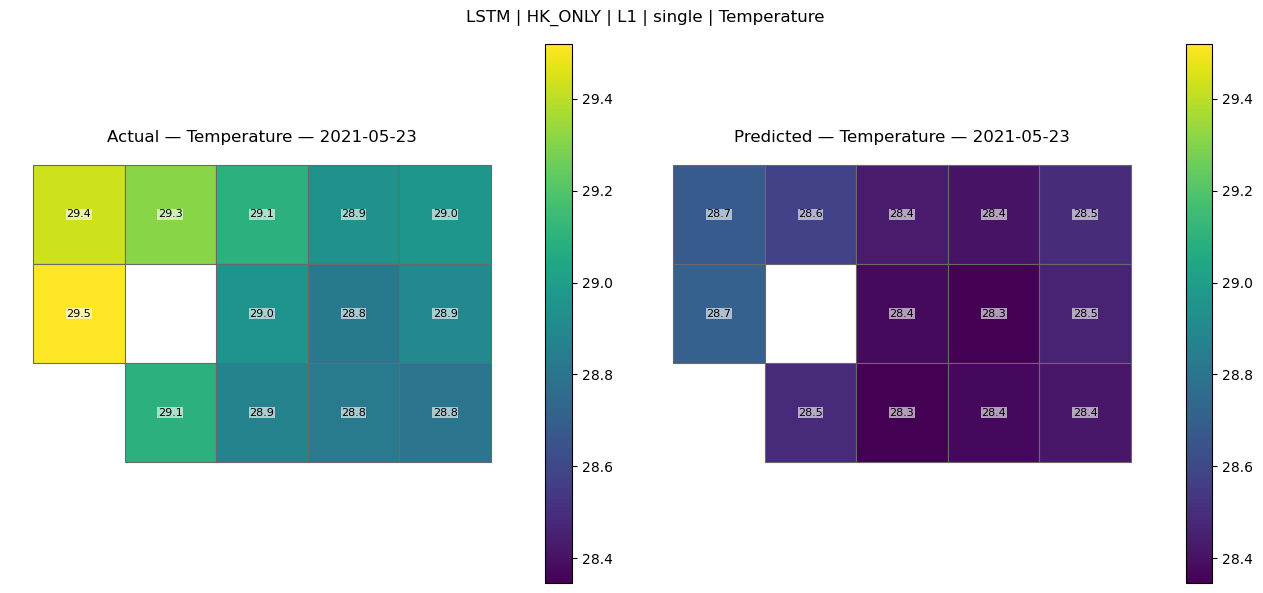

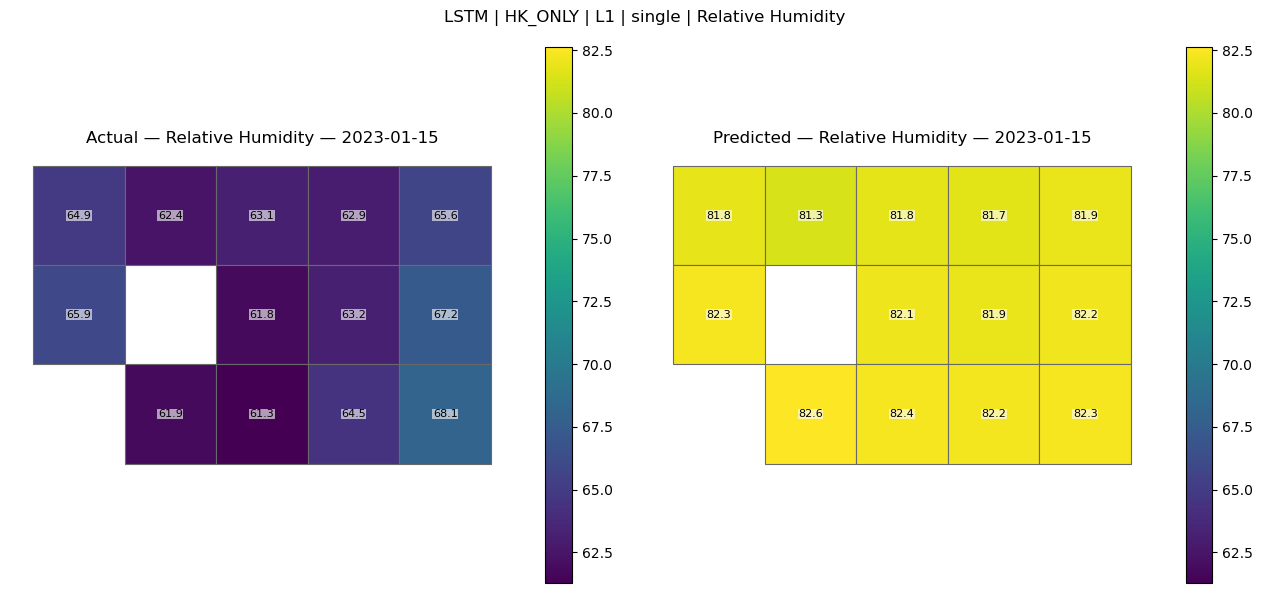

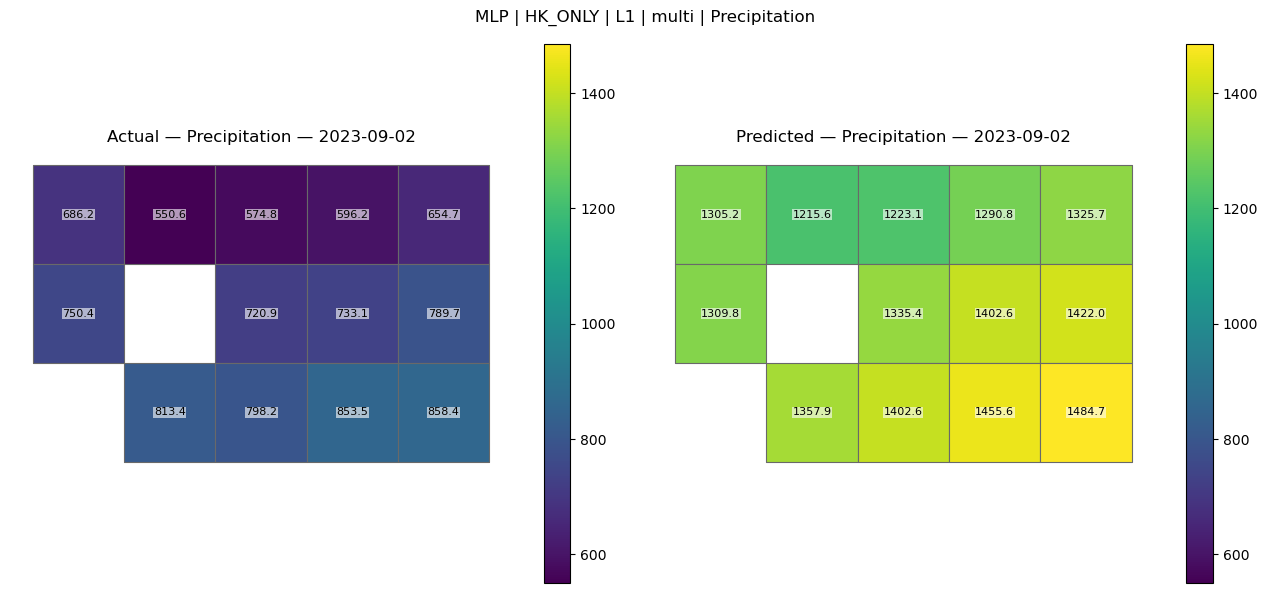

Sample days used:


,target,date,family_label,setting_run,model
0,t2m_mean,2021-05-23,LSTM,HK_L1_single_lstm,L1-LSTMseq14:t2m_mean-single
1,rh2m_mean,2023-01-15,LSTM,HK_L1_single_lstm,L1-LSTMseq14:rh2m_mean-single
2,tp_sum_mm,2023-09-02,MLP,HK_L1_multi_flat,L1-TorchMLP-multi


Saved: outputs/modelling_outputs/ANNOTATED_SAMPLE_DAYS_USED.csv


In [49]:
# ============================================================
# One random sample test day of Actual vs Predicted values per region for each target
# ============================================================

def _target_fmt(target):
    if target == "tp_sum_mm":
        return "{:.1f}"
    return "{:.1f}"

def _pick_one_random_day(pred_map, random_state=42):
    days = sorted(pd.to_datetime(pred_map["target_date"].dropna().unique()))
    if len(days) == 0:
        return None
    rng = np.random.default_rng(random_state)
    return pd.to_datetime(rng.choice(days))

def _plot_annotated_map_on_ax(gdf, col, ax, title, vmin=None, vmax=None, fmt="{:.1f}"):
    gdf.plot(
        column=col,
        ax=ax,
        legend=True,
        vmin=vmin,
        vmax=vmax,
        edgecolor="dimgray",
        linewidth=0.8,
        missing_kwds={"color": "lightgrey"}
    )

    reps = gdf.geometry.representative_point()
    for idx, r in gdf.iterrows():
        val = r.get(col, np.nan)
        if pd.notna(val):
            pt = reps.iloc[idx]
            ax.text(
                pt.x, pt.y, fmt.format(val),
                ha="center", va="center",
                fontsize=8,
                color="black",
                bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=0.3)
            )

    ax.set_title(title)
    ax.set_axis_off()

def plot_one_sample_day_actual_vs_pred(pred_map, row, grid_gdf, date=None, random_state=42):
    """
    pred_map: output from build_pred_map_from_row(...)
    row     : one row from RESOLVED_ROWS_DF
    grid_gdf: HK grid GeoDataFrame
    """
    t = row["target"]
    fmt = _target_fmt(t)

    if date is None:
        date = _pick_one_random_day(pred_map, random_state=random_state)

    if date is None:
        print(f"No valid date found for {t}.")
        return None

    date = pd.to_datetime(date)

    day_df = pred_map.loc[pred_map["target_date"] == date].copy()
    if len(day_df) == 0:
        print(f"No rows found for {t} on {date.date()}.")
        return None

    day_df["region_id"] = day_df["region_id"].astype(str)

    g = grid_gdf.copy()
    g["region_id"] = g["region_id"].astype(str)
    g = g.merge(
        day_df[["region_id", f"{t}_true", f"{t}_pred"]],
        on="region_id",
        how="left"
    )

    vals_true = g[f"{t}_true"].dropna().to_numpy()
    vals_pred = g[f"{t}_pred"].dropna().to_numpy()
    vals = np.concatenate([vals_true, vals_pred]) if (len(vals_true) + len(vals_pred)) > 0 else np.array([])

    vmin = float(np.nanmin(vals)) if len(vals) else None
    vmax = float(np.nanmax(vals)) if len(vals) else None

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))

    _plot_annotated_map_on_ax(
        gdf=g,
        col=f"{t}_true",
        ax=axes[0],
        title=f"Actual — {TARGET_LABELS.get(t, t)} — {date.date()}",
        vmin=vmin,
        vmax=vmax,
        fmt=fmt
    )

    _plot_annotated_map_on_ax(
        gdf=g,
        col=f"{t}_pred",
        ax=axes[1],
        title=f"Predicted — {TARGET_LABELS.get(t, t)} — {date.date()}",
        vmin=vmin,
        vmax=vmax,
        fmt=fmt
    )

    fig.suptitle(
        f"{row['family_label']} | {row['scenario']} | L{row['level']} | {row['mode']} | {TARGET_LABELS.get(t, t)}",
        y=0.98
    )
    plt.tight_layout()
    plt.show()

    return {
        "target": t,
        "date": date.date(),
        "family_label": row["family_label"],
        "setting_run": row["setting_run"],
        "model": row["model"]
    }

# ------------------------------------------------------------
# Run for all currently selected models in RESOLVED_ROWS_DF
# ------------------------------------------------------------
SAMPLE_DAY_ROWS = []

for i, (_, row) in enumerate(RESOLVED_ROWS_DF.iterrows()):
    key = f"{row['setting_run']}__{row['target']}__{row['family_key']}"

    # reuse cached pred_map if available, otherwise rebuild
    if "SELECTED_PRED_MAPS" in globals() and key in SELECTED_PRED_MAPS:
        pred_map = SELECTED_PRED_MAPS[key]
    else:
        pred_map = build_pred_map_from_row(row, split="test")

    info = plot_one_sample_day_actual_vs_pred(
        pred_map=pred_map,
        row=row,
        grid_gdf=grid_plot,
        date=None,                 # random day
        random_state=42 + i
    )

    if info is not None:
        SAMPLE_DAY_ROWS.append(info)

SAMPLE_DAY_TABLE = pd.DataFrame(SAMPLE_DAY_ROWS)
print("Sample days used:")
display(SAMPLE_DAY_TABLE)

SAMPLE_DAY_SAVE = Path(SAVE_DIR) / "ANNOTATED_SAMPLE_DAYS_USED.csv"
SAMPLE_DAY_TABLE.to_csv(SAMPLE_DAY_SAVE, index=False)
print("Saved:", SAMPLE_DAY_SAVE)

# row = RESOLVED_ROWS_DF.iloc[0]
# pred_map = build_pred_map_from_row(row, split="test")

# plot_one_sample_day_actual_vs_pred(
#     pred_map=pred_map,
#     row=row,
#     grid_gdf=grid_plot,
#     date="2023-08-15"
# )

In [50]:
# ============================================================
# Permutation importance
#    flat -> existing permutation_importance_rmse
#    lstm -> sequence-aware version
# ============================================================

def permutation_importance_rmse(model, X, y, feature_cols, n_repeats=5, target_idx=None):
    """
    Permutation importance using negative RMSE.
    Works for both:
      - single-output models
      - multi-output models, by selecting target_idx
    """
    X = np.asarray(X)
    y = np.asarray(y).astype(float).ravel()

    def scorer(est, Xb, yb):
        pred = np.asarray(est.predict(Xb))

        if pred.ndim == 2:
            if target_idx is None:
                pred = pred[:, 0]
            else:
                pred = pred[:, target_idx]

        pred = np.asarray(pred).astype(float).ravel()
        return -rmse(yb, pred)

    r = permutation_importance(
        model,
        X,
        y,
        scoring=scorer,
        n_repeats=n_repeats,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    out = pd.DataFrame({
        "feature": feature_cols,
        "importance": r.importances_mean,
        "importance_std": r.importances_std
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    return out


def permutation_importance_lstm_seq(row, split="val", n_repeats=5, random_state=42, seq_len=14):
    setting_run = row["setting_run"]
    res = RES_MAP[setting_run]
    feature_cols = res["features"]
    target = row["target"]

    df_part = build_split_from_row(row, res, split=split)
    bundle = res["fitted"][row["model"]]

    if row["mode"] == "single":
        target_cols = [f"{target}_tplus1"]
    else:
        target_cols = [f"{t}_tplus1" for t in TARGETS]

    X_seq, Y_seq, _ = build_sequences_for_lstm(
        df_part,
        feature_cols=feature_cols,
        target_cols=target_cols,
        time_col="time",
        seq_len=seq_len
    )

    target_idx = 0 if row["mode"] == "single" else TARGETS.index(target)

    pred0, true0, _, _ = predict_with_lstm_bundle(bundle, X_seq, Y_seq)
    base_rmse = rmse(true0[:, target_idx], pred0[:, target_idx])

    rng = np.random.default_rng(random_state)
    rows = []

    for j, feat in enumerate(feature_cols):
        scores = []
        for _ in range(n_repeats):
            Xp = X_seq.copy()
            perm_idx = rng.permutation(Xp.shape[0])
            Xp[:, :, j] = Xp[perm_idx, :, j]

            pred_p, true_p, _, _ = predict_with_lstm_bundle(bundle, Xp, Y_seq)
            score = rmse(true_p[:, target_idx], pred_p[:, target_idx]) - base_rmse
            scores.append(score)

        rows.append({
            "feature": feat,
            "importance": float(np.mean(scores)),
            "importance_std": float(np.std(scores))
        })

    return pd.DataFrame(rows).sort_values("importance", ascending=False).reset_index(drop=True)

def compute_importance_for_row(row, split="val", n_repeats=5):
    setting_run = row["setting_run"]
    res = RES_MAP[setting_run]
    feature_cols = res["features"]
    target = row["target"]
    target_idx = TARGETS.index(target)

    if row["source"] == "flat":
        model_obj = res["fitted"][row["fitted_key"]]
        df_part = build_split_from_row(row, res, split=split)
        X, Y = get_XY(df_part, feature_cols)

        if row["mode"] == "multi":
            imp = permutation_importance_rmse(
                model_obj, X, Y[:, target_idx], feature_cols,
                n_repeats=n_repeats, target_idx=target_idx
            )
        else:
            imp = permutation_importance_rmse(
                model_obj, X, Y[:, target_idx], feature_cols,
                n_repeats=n_repeats, target_idx=None
            )

        return imp.reset_index(drop=True)

    elif row["source"] == "lstm":
        return permutation_importance_lstm_seq(row, split=split, n_repeats=n_repeats)

    else:
        raise ValueError("Unknown source type.")

def plot_top10_importance_bar_and_table(imp_df, row, topk=10):
    top = imp_df.head(topk).copy()
    top["rank"] = np.arange(1, len(top) + 1)

    print("\n" + "=" * 90)
    print(f"Top {topk} permutation-important features | {row['family_label']} | {row['target']}")
    display(top[["rank", "feature", "importance"]])

    plot_df = top.sort_values("importance", ascending=True)

    plt.figure(figsize=(8, 5))
    plt.barh(plot_df["feature"], plot_df["importance"])
    plt.title(
        f"Top {topk} permutation-important features\n"
        f"{row['family_label']} | {row['scenario']} | L{row['level']} | {row['mode']} | "
        f"{TARGET_LABELS.get(row['target'], row['target'])}"
    )
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    return top[["rank", "feature", "importance"]].copy()




VISUALISING -> LSTM | HK_ONLY | L1 | single | t2m_mean
Saved: outputs/modelling_outputs/HK_L1_single_lstm__t2m_mean__LSTM__pred_map.csv


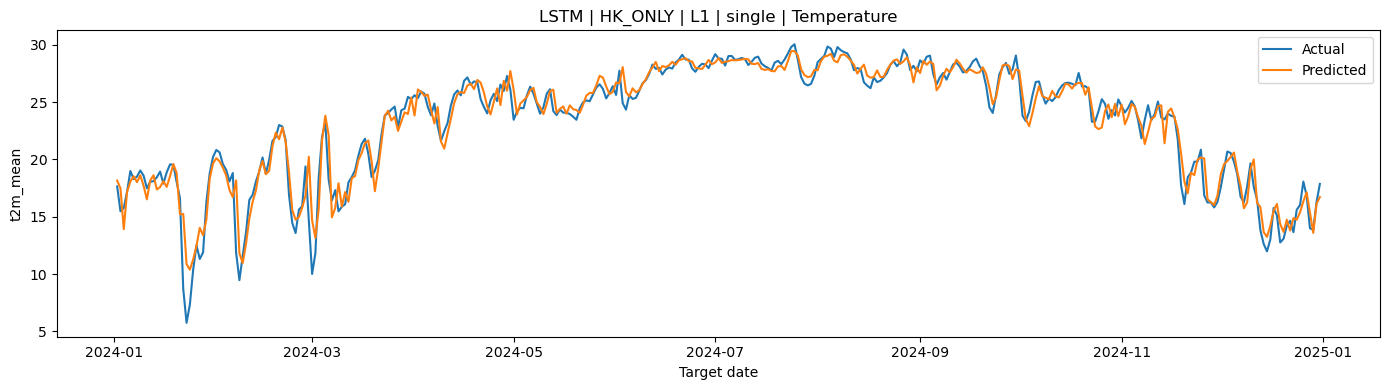

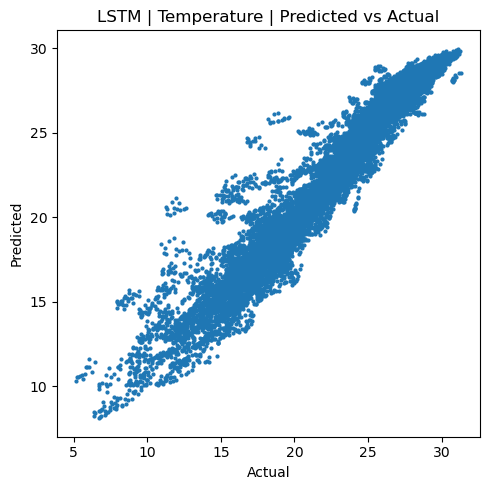

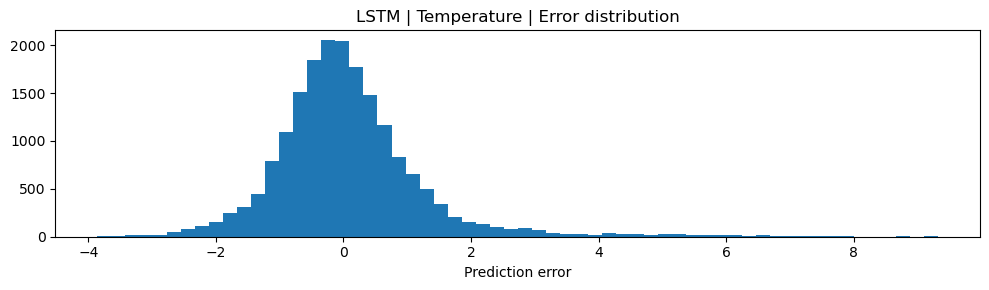

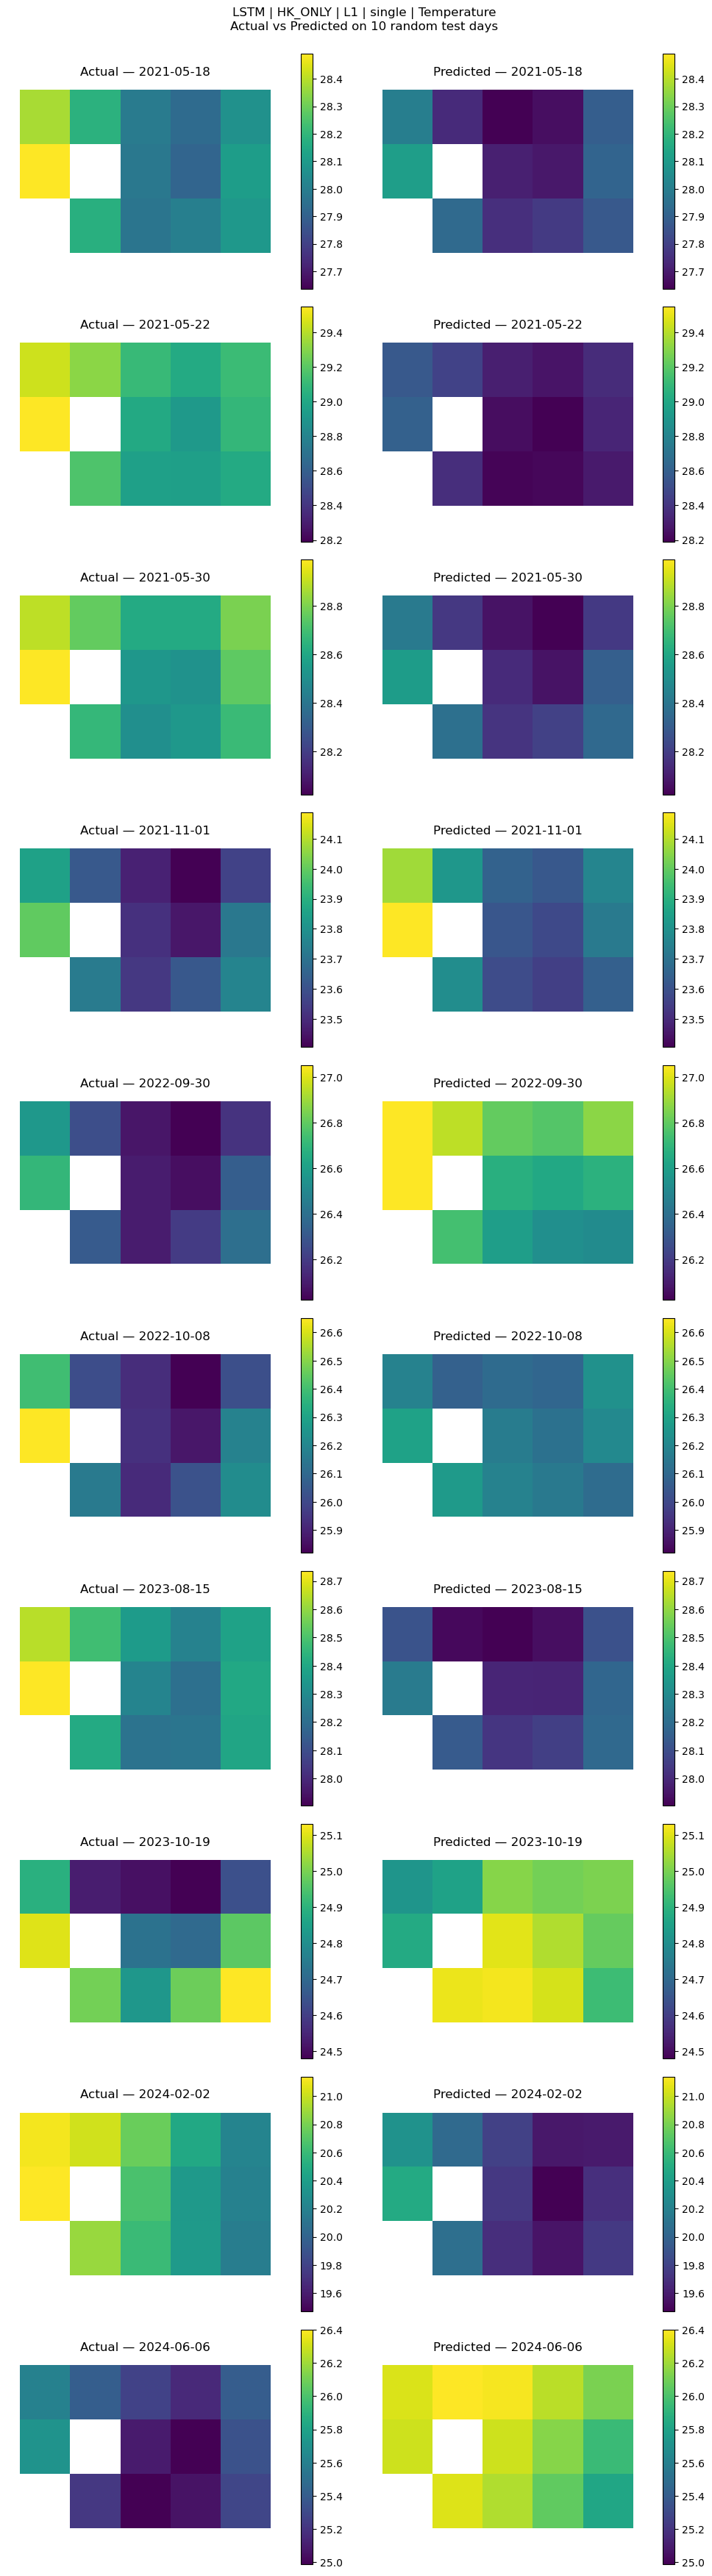


Top 10 permutation-important features | LSTM | t2m_mean


,rank,feature,importance
0,1,t2m_mean,3.745336
1,2,doy_cos,0.983373
2,3,v10_mean,0.343461
3,4,doy_sin,0.159977
4,5,tp_sum_mm,0.086351
5,6,rh2m_mean,0.056314
6,7,sp_mean,0.048362
7,8,u10_mean,0.043665
8,9,ssrd_mj_m2,0.028006
9,10,year,0.001712


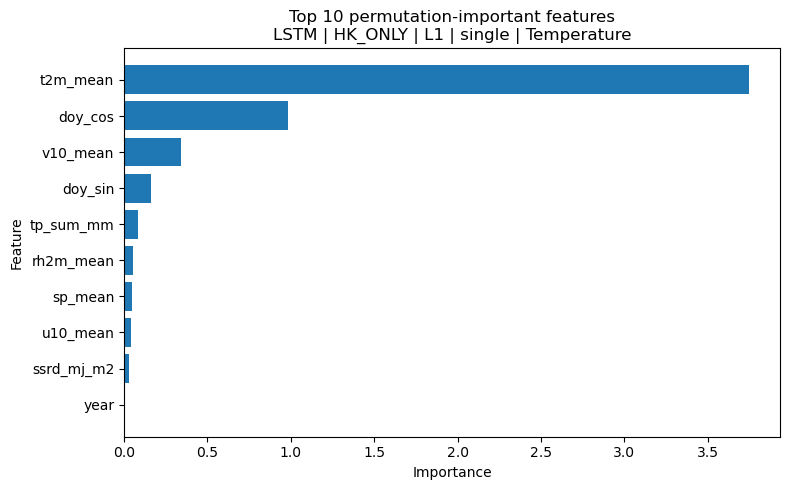


VISUALISING -> LSTM | HK_ONLY | L1 | single | rh2m_mean
Saved: outputs/modelling_outputs/HK_L1_single_lstm__rh2m_mean__LSTM__pred_map.csv


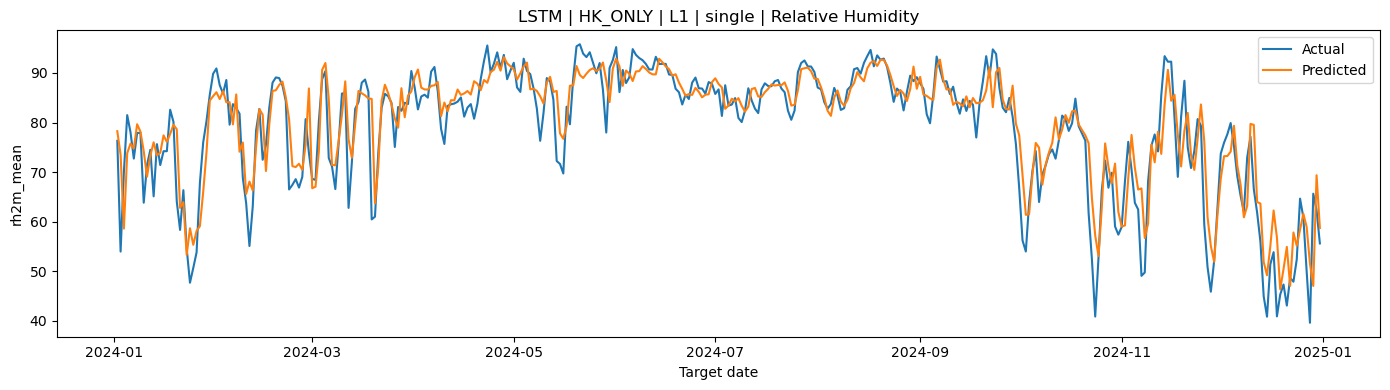

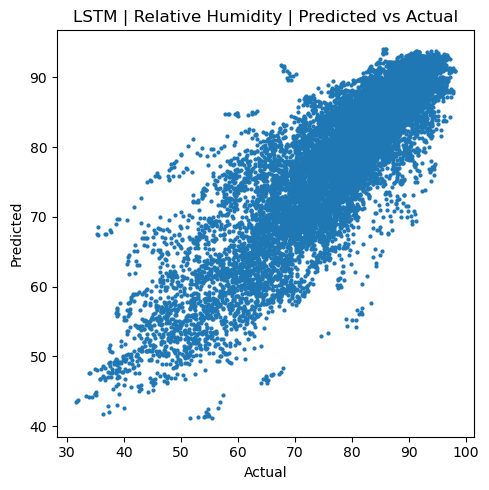

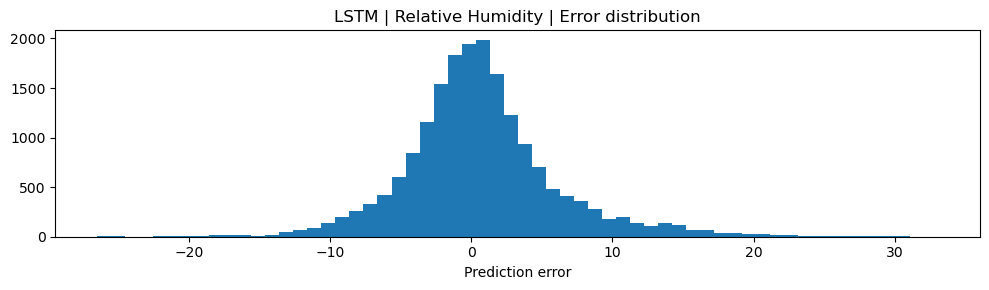

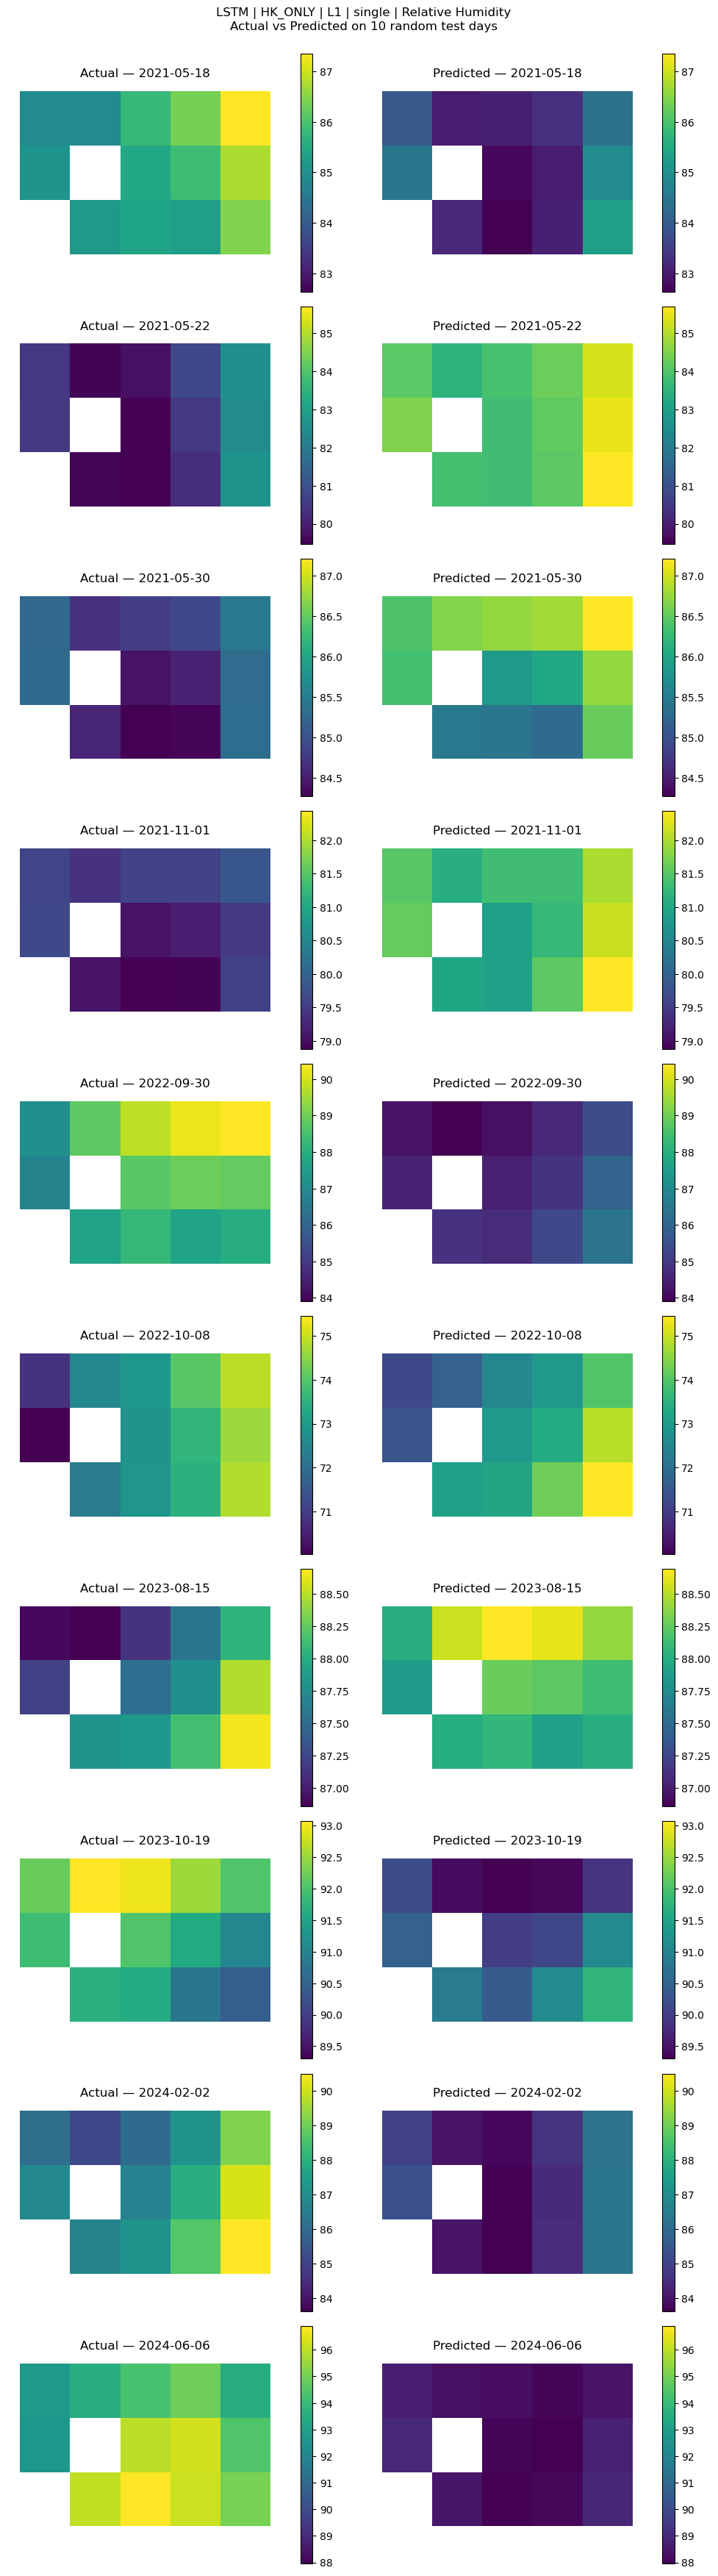


Top 10 permutation-important features | LSTM | rh2m_mean


,rank,feature,importance
0,1,rh2m_mean,5.790542
1,2,v10_mean,0.857336
2,3,u10_mean,0.619801
3,4,sp_mean,0.306695
4,5,doy_cos,0.293953
5,6,ssrd_mj_m2,0.214432
6,7,tp_sum_mm,0.156832
7,8,t2m_mean,0.124632
8,9,doy_sin,0.040023
9,10,year,-0.002444


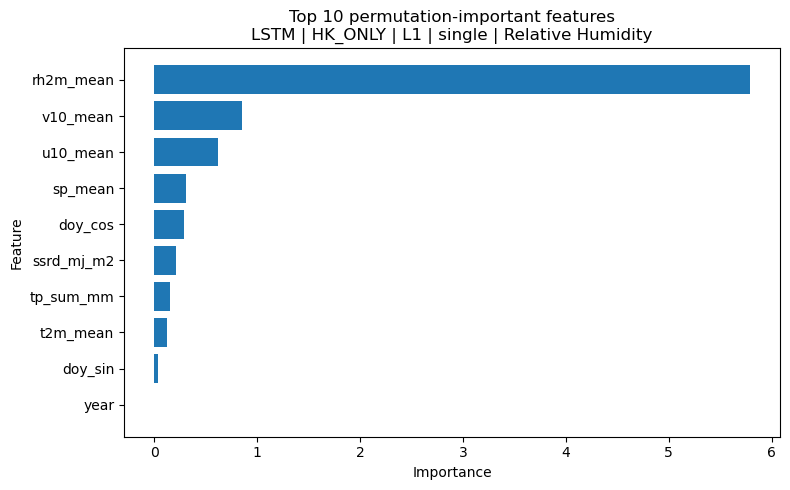


VISUALISING -> MLP | HK_ONLY | L1 | multi | tp_sum_mm
Saved: outputs/modelling_outputs/HK_L1_multi_flat__tp_sum_mm__MLP__pred_map.csv


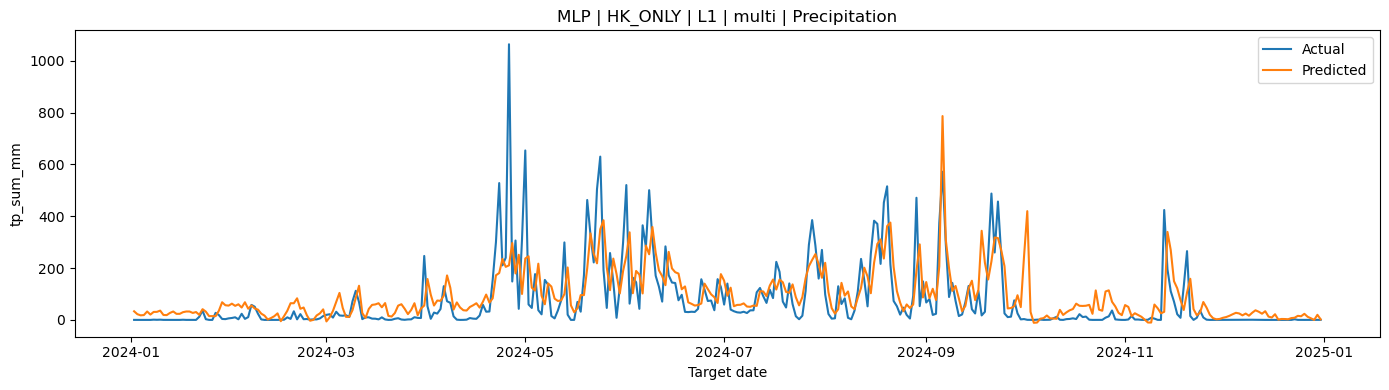

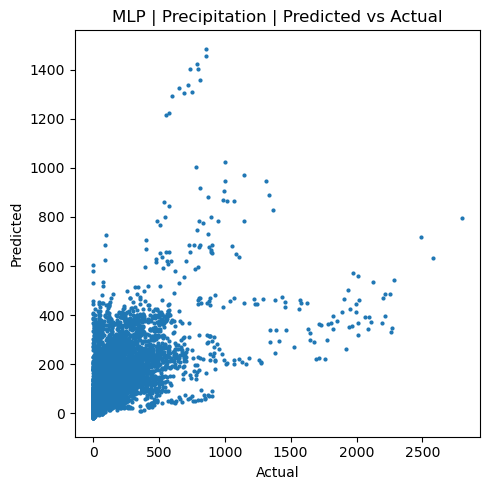

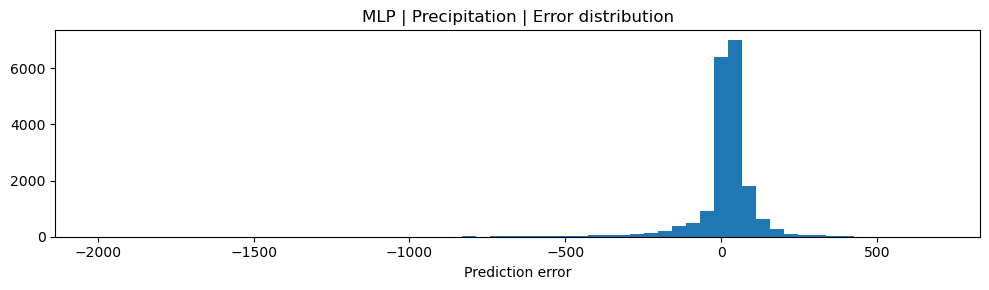

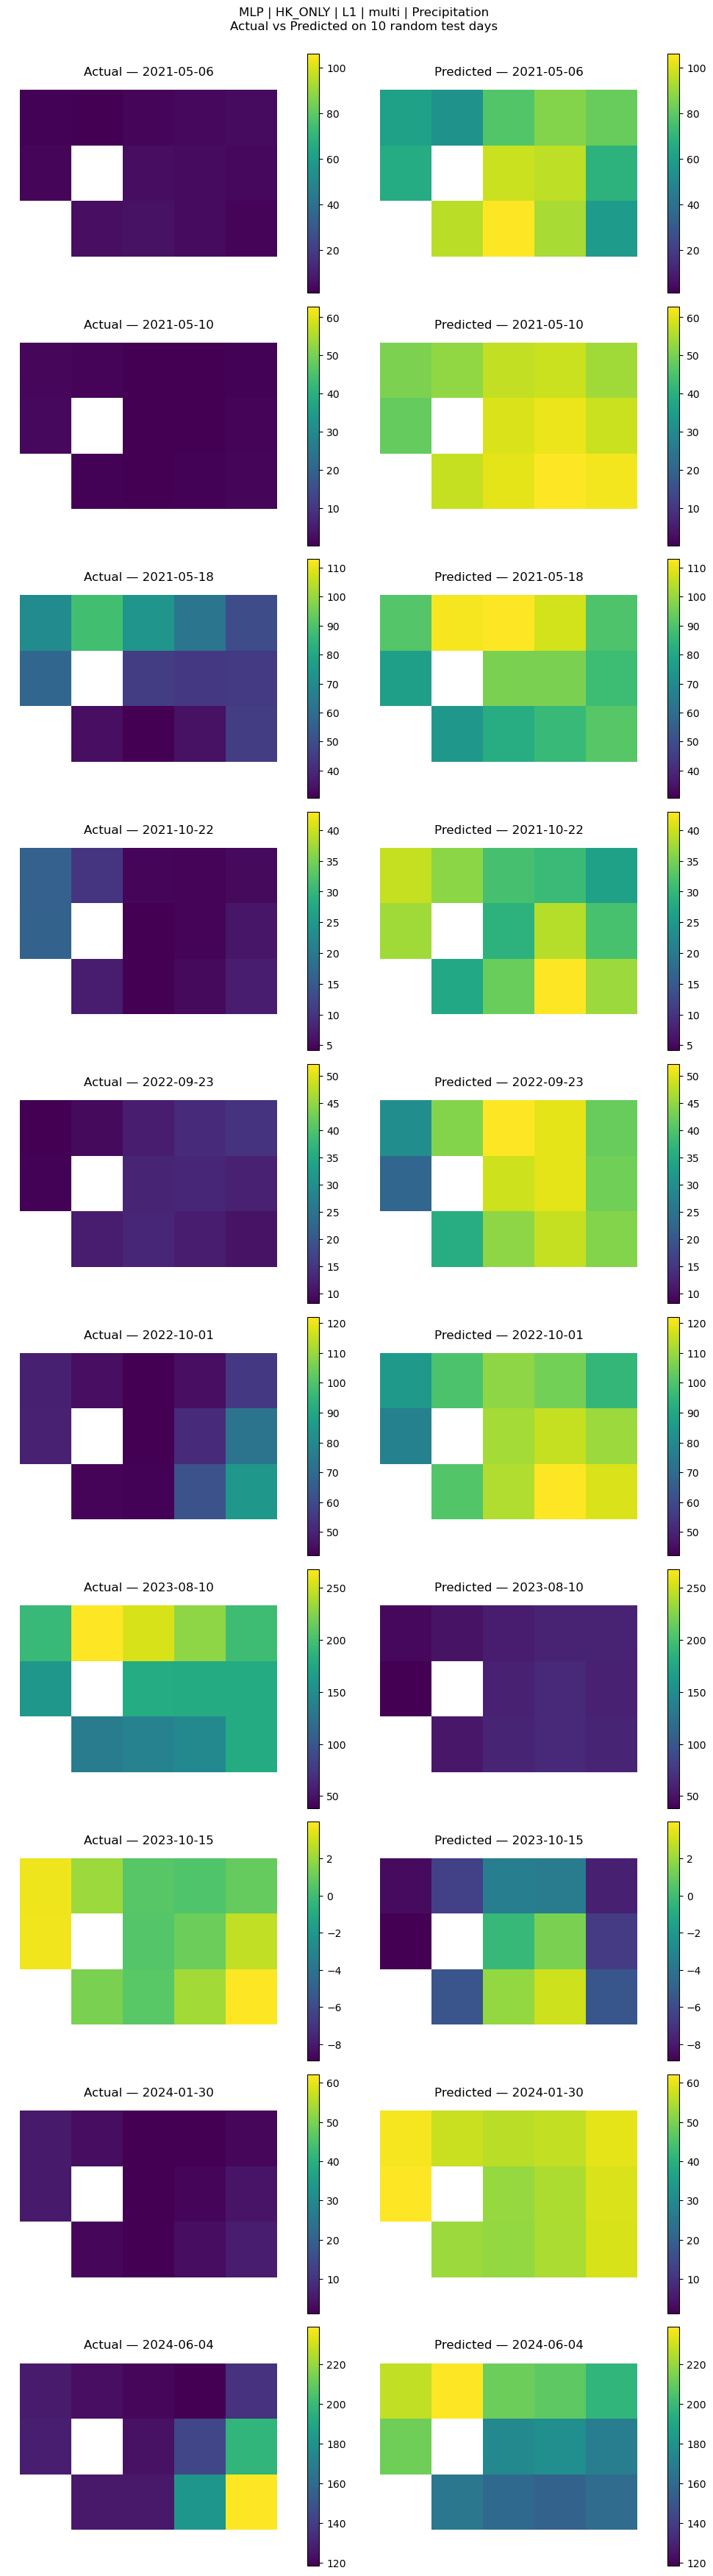


Top 10 permutation-important features | MLP | tp_sum_mm


,rank,feature,importance
0,1,v10_mean,67.197334
1,2,t2m_mean,26.659600
2,3,tp_sum_mm,22.431514
3,4,doy_cos,9.068099
4,5,sp_mean,6.550505
5,6,rh2m_mean,6.359607
6,7,ssrd_mj_m2,4.534535
7,8,u10_mean,3.242990
8,9,doy_sin,1.811232
9,10,year,0.033676


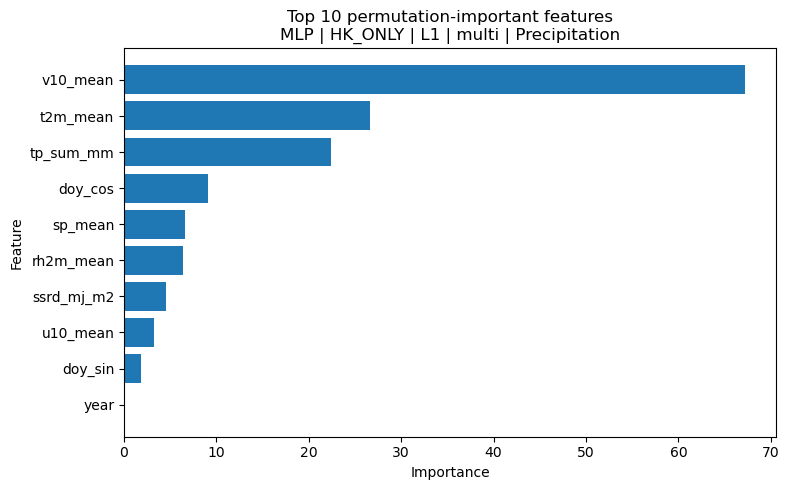


Combined Top-10 importance table for selected models


,rank,feature,importance,setting_run,scenario,level,mode,source,family_label,target
0,1,t2m_mean,3.745336,HK_L1_single_lstm,HK_ONLY,1,single,lstm,LSTM,t2m_mean
1,2,doy_cos,0.983373,HK_L1_single_lstm,HK_ONLY,1,single,lstm,LSTM,t2m_mean
2,3,v10_mean,0.343461,HK_L1_single_lstm,HK_ONLY,1,single,lstm,LSTM,t2m_mean
3,4,doy_sin,0.159977,HK_L1_single_lstm,HK_ONLY,1,single,lstm,LSTM,t2m_mean
4,5,tp_sum_mm,0.086351,HK_L1_single_lstm,HK_ONLY,1,single,lstm,LSTM,t2m_mean
5,6,rh2m_mean,0.056314,HK_L1_single_lstm,HK_ONLY,1,single,lstm,LSTM,t2m_mean
6,7,sp_mean,0.048362,HK_L1_single_lstm,HK_ONLY,1,single,lstm,LSTM,t2m_mean
7,8,u10_mean,0.043665,HK_L1_single_lstm,HK_ONLY,1,single,lstm,LSTM,t2m_mean
8,9,ssrd_mj_m2,0.028006,HK_L1_single_lstm,HK_ONLY,1,single,lstm,LSTM,t2m_mean
9,10,year,0.001712,HK_L1_single_lstm,HK_ONLY,1,single,lstm,LSTM,t2m_mean


Saved: outputs/modelling_outputs/TOP10_IMPORTANCE_SELECTED_MODELS.csv


In [51]:
# ============================================================
# Run visualisations for selected models
# ============================================================

SELECTED_PRED_MAPS = {}
TOP10_TABLES = []

for _, row in RESOLVED_ROWS_DF.iterrows():
    print("\n" + "=" * 110)
    print(
        f"VISUALISING -> {row['family_label']} | {row['scenario']} | "
        f"L{row['level']} | {row['mode']} | {row['target']}"
    )

    pred_map = build_pred_map_from_row(row, split="test", seq_len=14)
    cache_key = f"{row['setting_run']}__{row['target']}__{row['family_key']}"
    SELECTED_PRED_MAPS[cache_key] = pred_map

    # save the raw prediction map
    pred_save = Path(SAVE_DIR) / f"{cache_key}__pred_map.csv"
    pred_map.to_csv(pred_save, index=False)
    print("Saved:", pred_save)

    plot_daily_mean_timeseries(pred_map, row, max_days=365)
    plot_scatter_and_error(pred_map, row)
    plot_random_day_maps(pred_map, row, grid_plot, n_days=10, random_state=42)

    imp_df = compute_importance_for_row(row, split="val", n_repeats=5)
    top10 = plot_top10_importance_bar_and_table(imp_df, row, topk=10)
    top10["setting_run"] = row["setting_run"]
    top10["scenario"] = row["scenario"]
    top10["level"] = row["level"]
    top10["mode"] = row["mode"]
    top10["source"] = row["source"]
    top10["family_label"] = row["family_label"]
    top10["target"] = row["target"]
    TOP10_TABLES.append(top10)

TOP10_IMPORTANCE_TABLE = pd.concat(TOP10_TABLES, ignore_index=True)
print("\nCombined Top-10 importance table for selected models")
display(TOP10_IMPORTANCE_TABLE)

TOP10_SAVE = Path(SAVE_DIR) / "TOP10_IMPORTANCE_SELECTED_MODELS.csv"
TOP10_IMPORTANCE_TABLE.to_csv(TOP10_SAVE, index=False)
print("Saved:", TOP10_SAVE)